# Project 11 -- Vinay Gannamaneni

**TA Help:** (for instance) John Smith, Alice Jones, etc., list names of any TAs who helped you

- For example: Help with figuring out how to write a function (describe the tasks that they helped you with)

**Collaboration:** My Friend in CS, My Uncle, Another Student, etc., list names of any other people who helped you

(describe the tasks that they helped you with)
- For example: helped figuring out how to load the dataset.
- Another example: helped debug error with my plot.

**Internet Resources:** Stack Exchange, Stack Overflow, etc.

(describe any information that you learned from internet resources, including the URLs)
- data frames in Pandas versus R from StackOverflow  https://stackoverflow.com/questions/8991709/why-were-pandas-merges-in-python-faster-than-data-table-merges-in-r-in-2012

**ChatGPT, Gemini, Claude, etc:** Any language models or generative AI chatbots that helped you.

(if you used any such tools, please tell us here)
- For example:  I asked ChatGPT how to define a new data frames
- Another example:  Gemini told me how to make a function for sorting my data

- ***Link to AI Chat History***: Please share a link to your chat if you used AI (ex. ChatGPT Shared Links)
**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Comparing days-on-market by state and by census region

In [1]:
library(ggplot2)
library(dplyr)

myDF <- read.csv('/anvil/projects/tdm/data/zillow/State_time_series.csv')


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [2]:
myDF_clean <- myDF %>%
  filter(!is.na(DaysOnZillow_AllHomes))

Filter for non-NA DaysOnZillow_AllHomes

In [3]:
length(unique(myDF_clean$RegionName))
unique(myDF_clean$RegionName)

[1] 51

[1] "Alabama"            "Alaska"             "Arizona"           
 [4] "Arkansas"           "California"         "Colorado"          
 [7] "Connecticut"        "Delaware"           "DistrictofColumbia"
[10] "Florida"            "Georgia"            "Hawaii"            
[13] "Idaho"              "Illinois"           "Indiana"           
[16] "Iowa"               "Kansas"             "Kentucky"          
[19] "Louisiana"          "Maine"              "Maryland"          
[22] "Massachusetts"      "Michigan"           "Minnesota"         
[25] "Mississippi"        "Missouri"           "Montana"           
[28] "Nebraska"           "Nevada"             "NewHampshire"      
[31] "NewJersey"          "NewMexico"          "NewYork"           
[34] "NorthCarolina"      "NorthDakota"        "Ohio"              
[37] "Oklahoma"           "Oregon"             "Pennsylvania"      
[40] "RhodeIsland"        "SouthCarolina"      "Tennessee"         
[43] "Texas"              "UnitedStates"       "Utah"              
[46] "Vermont"            "Virginia"           "Washington"        
[49] "WestVirginia"       "Wisconsin"          "Wyoming"

Check unique RegionName values

Create a boxplot for each region

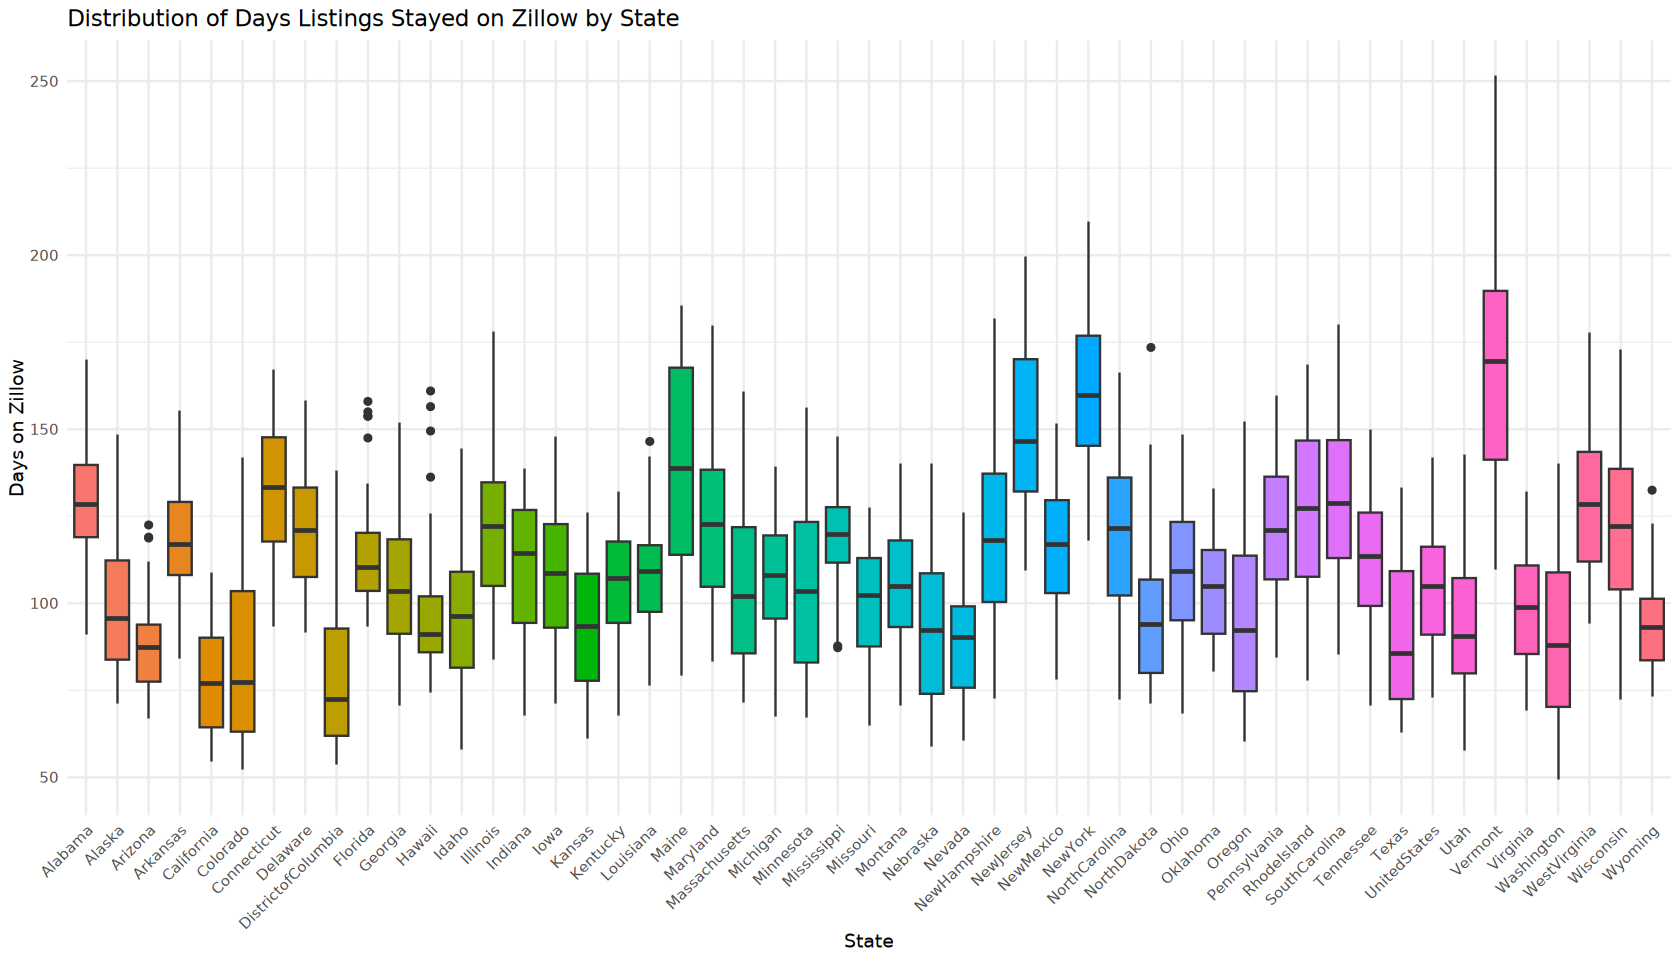

In [4]:
options(repr.plot.width = 14, repr.plot.height = 8)

ggplot(myDF_clean, aes(x = RegionName, y = DaysOnZillow_AllHomes, fill = RegionName)) +
  geom_boxplot() + 
  labs(
    title = "Distribution of Days Listings Stayed on Zillow by State",
    x = "State",
    y = "Days on Zillow",
    fill = "State"
  ) +
  theme_minimal() + 
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1), 
    legend.position = "none"  
  )

In [5]:
the_northeast <- c('Connecticut', 'Maine', 'Massachusetts', 'NewHampshire', 'NewJersey', 'NewYork', 'Pennsylvania', 'RhodeIsland', 'Vermont')
the_midwest <- c('Illinois', 'Indiana', 'Iowa', 'Kansas', 'Michigan', 'Minnesota', 'Missouri', 'Nebraska', 'NorthDakota', 'Ohio', 'Wisconsin')
the_south <- c('Alabama', 'Arkansas', 'Delaware', 'DistrictofColumbia', 'Florida', 'Georgia', 'Kentucky', 'Louisiana', 'Maryland', 'Mississippi', 'NorthCarolina', 'Oklahoma', 'SouthCarolina', 'Tennessee', 'Texas', 'Virginia', 'WestVirginia')
the_west <- c('Alaska', 'Arizona', 'California', 'Colorado', 'Hawaii', 'Idaho', 'Montana', 'Nevada', 'NewMexico', 'Oregon', 'Utah', 'Washington', 'Wyoming')

myDF_clean <- myDF_clean %>%
  mutate(CensusRegion = case_when(
    RegionName %in% the_northeast ~ "Northeast",
    RegionName %in% the_midwest ~ "Midwest",
    RegionName %in% the_south ~ "South",
    RegionName %in% the_west ~ "West",
    TRUE ~ "Other"
  ))

Define regions according to US Census Bureau and create new column for Census region

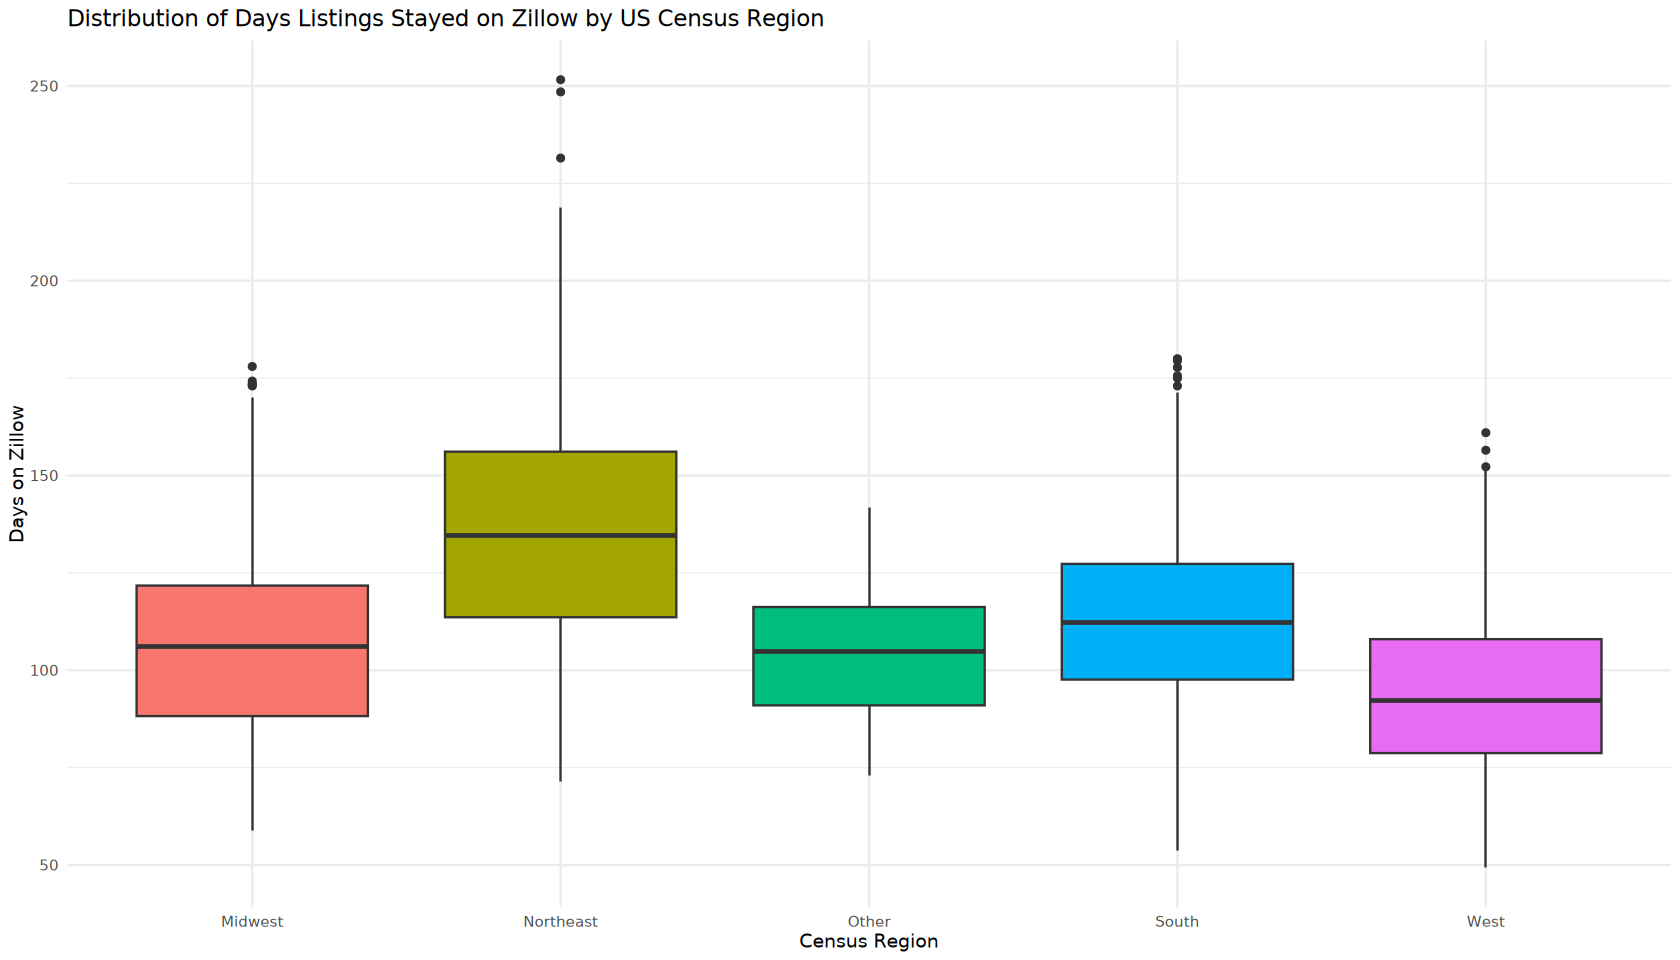

In [6]:
ggplot(myDF_clean, aes(x = CensusRegion, y = DaysOnZillow_AllHomes, fill = CensusRegion)) +
  geom_boxplot() +
  labs(
    title = "Distribution of Days Listings Stayed on Zillow by US Census Region",
    x = "Census Region",
    y = "Days on Zillow",
    fill = "Census Region"
  ) +
  theme_minimal() +
  theme(
    legend.position = "none"
  )

Boxplot by Census Region

Interpretation:
- The Northeast has the longest median Days on Zillow (approximately 135 days) and the greatest overall data variability (tallest box and highest outlier).
- This may reflect regional differences in housing demand, population density, and market activity.
- The West region exhibits the shortest median Days on Zillow (approximately 95 days), suggesting the fastest typical market turnover.
- The Midwest and South show similar, moderate median times (around 100-105 days), with the least variability among the four main regions.

## Housing supply vs. demand across U.S. regions

Create scatterplot with regions colored

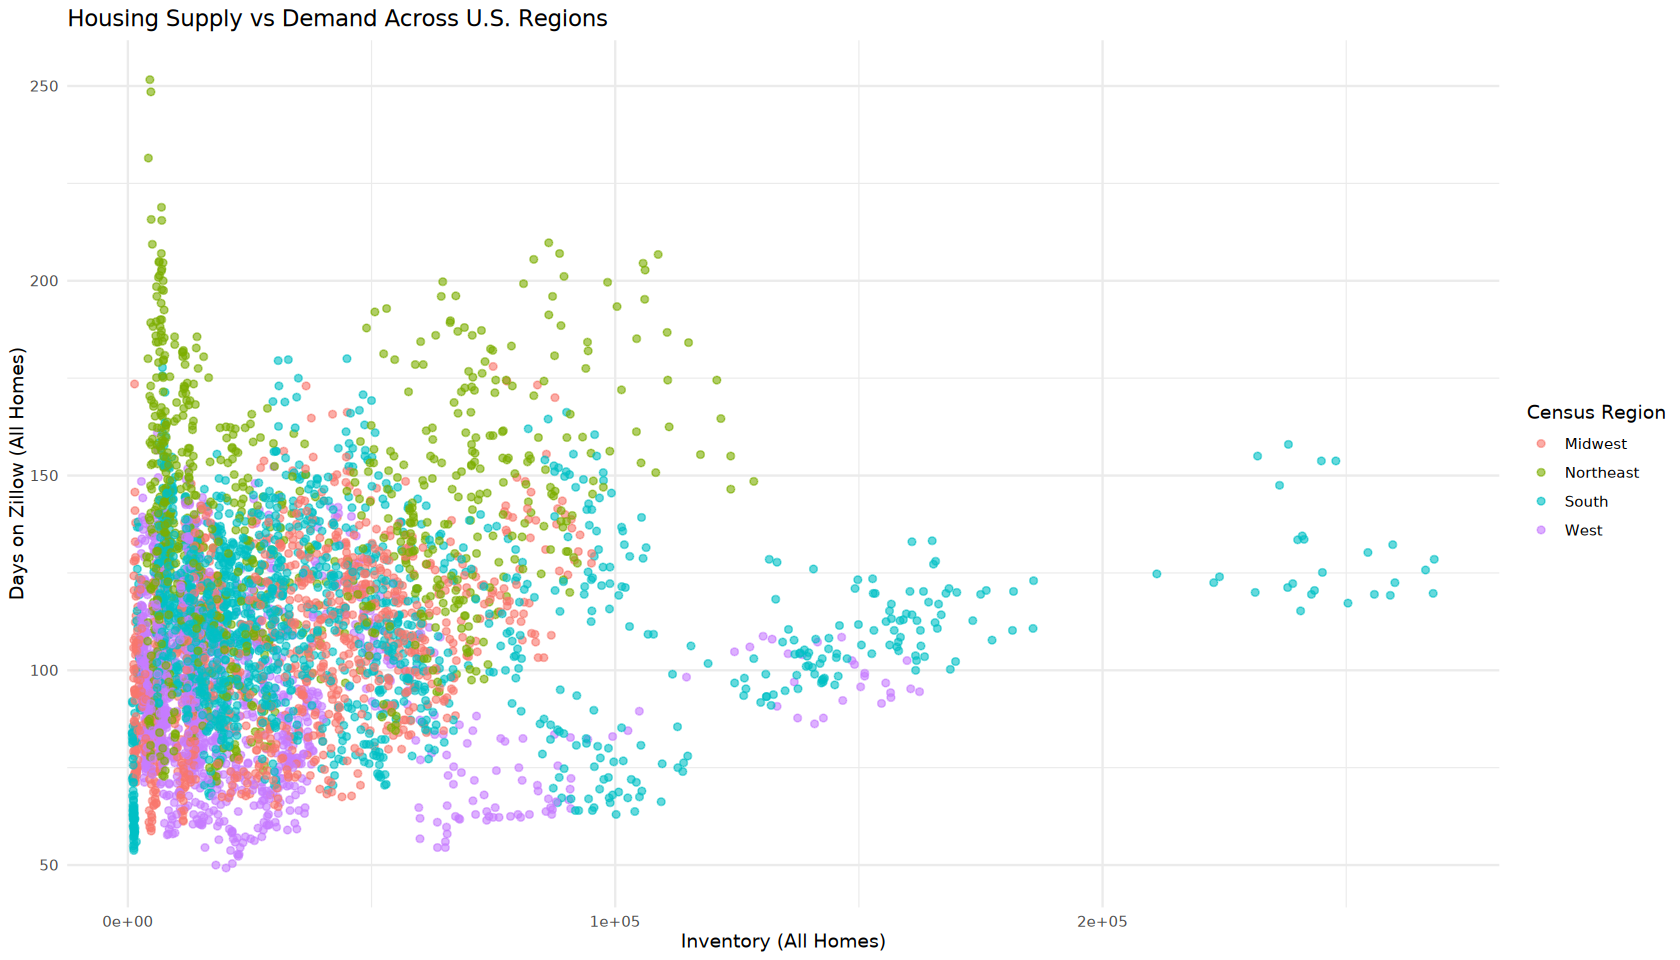

In [7]:
ggplot(myDF_clean %>% filter(CensusRegion != "Other"), 
       aes(x = InventoryRaw_AllHomes, y = DaysOnZillow_AllHomes, color = CensusRegion)) +
  geom_point(alpha = 0.6) +
  labs(title = "Housing Supply vs Demand Across U.S. Regions",
       x = "Inventory (All Homes)",
       y = "Days on Zillow (All Homes)",
       color = "Census Region") +
  theme_minimal()

I chose not to plot the "Other" region because it likely contains the aggregate "United States" entry or other non-state entries that would skew the state-level analysis and don't represent a meaningful geographic region for comparison.

In [8]:
library(patchwork)

p_midwest <- ggplot(myDF_clean %>% filter(CensusRegion == "Midwest"),
                     aes(x = InventoryRaw_AllHomes, y = DaysOnZillow_AllHomes)) +
  geom_point(color = "skyblue", alpha = 0.6) +
  labs(title = "Midwest: Supply vs Demand",
       x = "Inventory (All Homes)",
       y = "Days on Zillow (All Homes)") +
  theme_minimal()

p_south <- ggplot(myDF_clean %>% filter(CensusRegion == "South"),
                   aes(x = InventoryRaw_AllHomes, y = DaysOnZillow_AllHomes)) +
  geom_point(color = "violet", alpha = 0.6) +
  labs(title = "South: Supply vs Demand",
       x = "Inventory (All Homes)",
       y = "Days on Zillow (All Homes)") +
  theme_minimal()

Create plots for Midwest and South. Then, display side by side

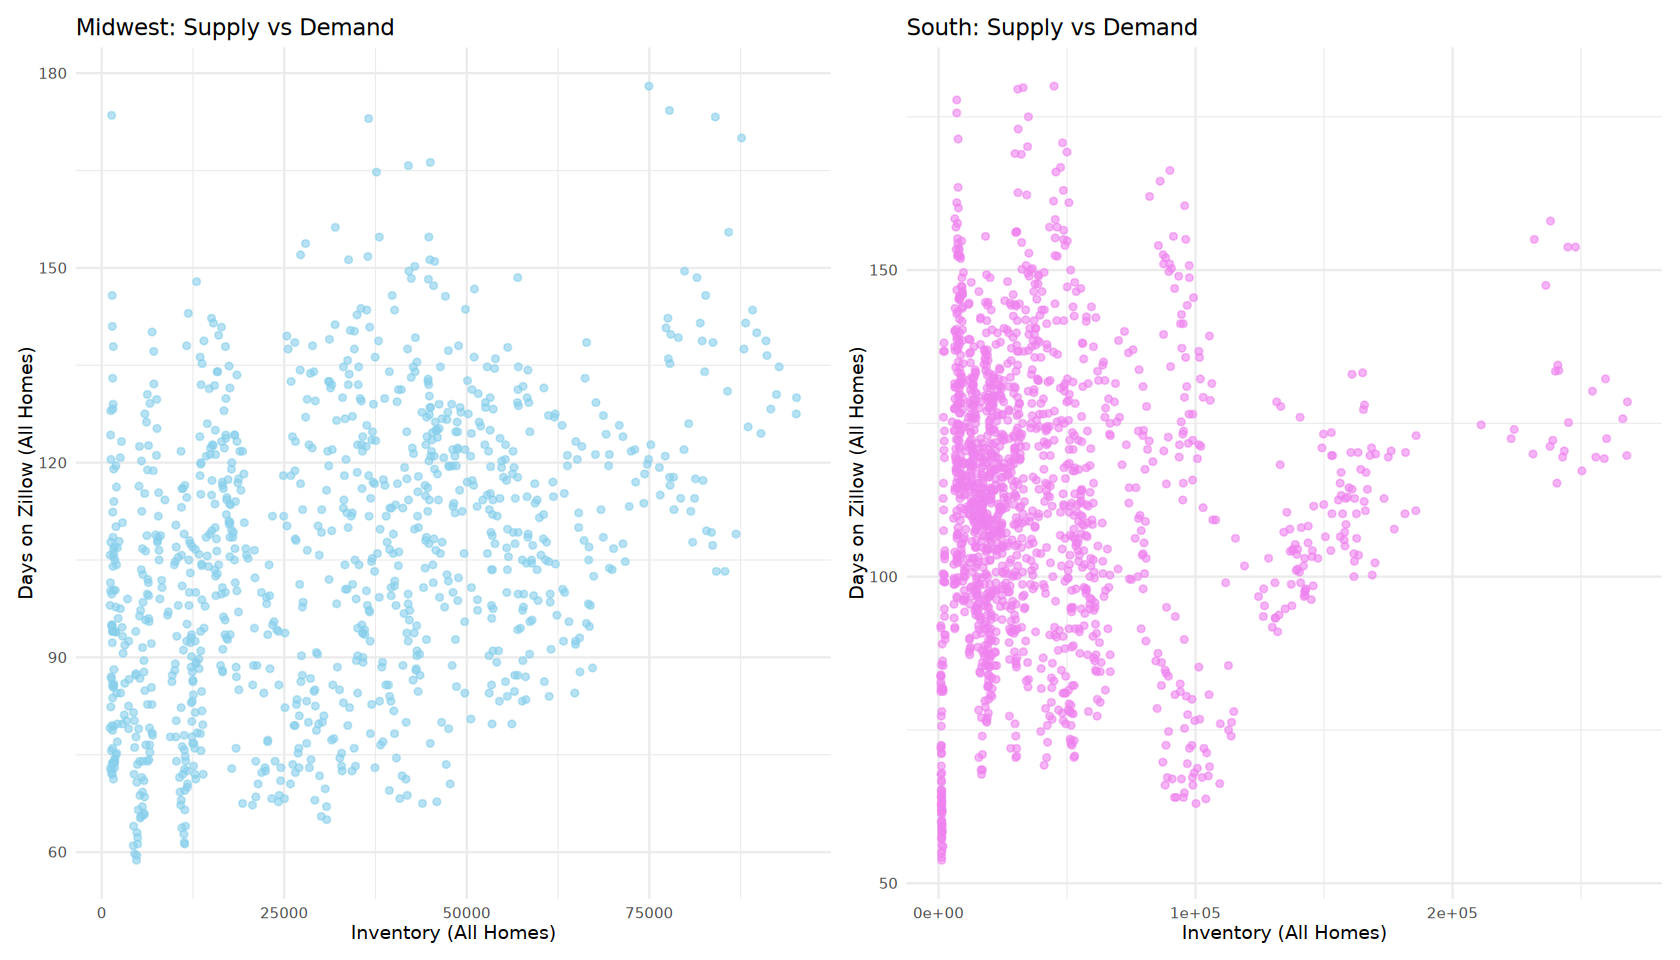

In [9]:
p_midwest + p_south

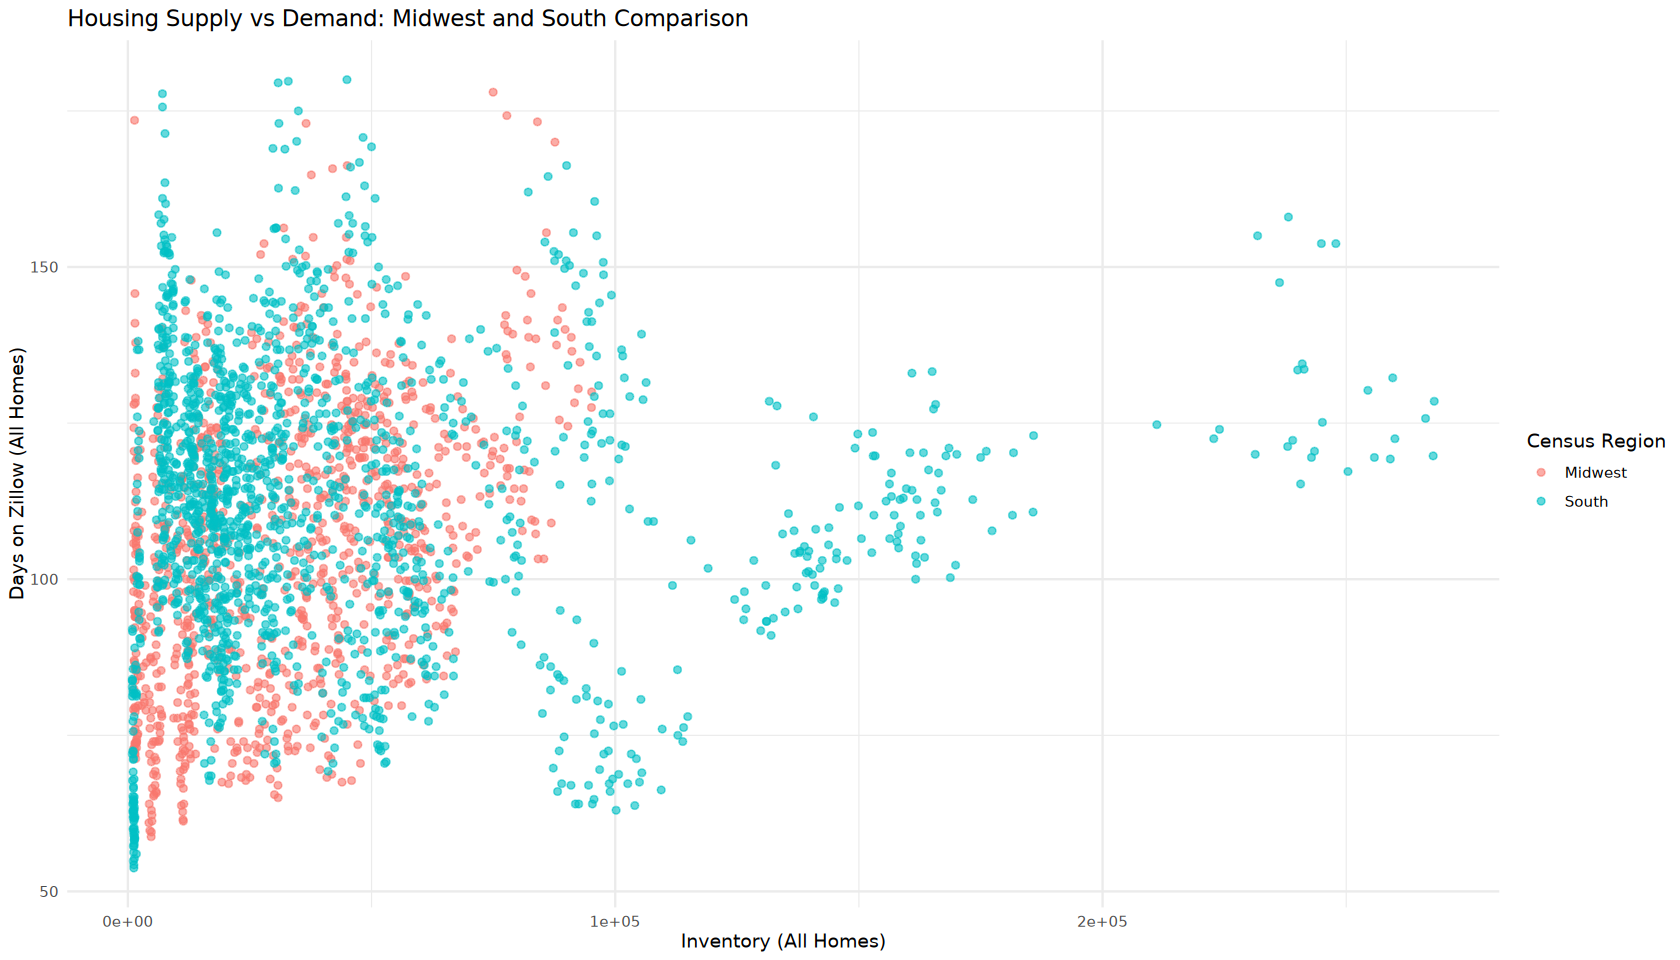

In [10]:
ggplot() +
  geom_point(data = myDF_clean %>% filter(CensusRegion == "Midwest"),
             aes(x = InventoryRaw_AllHomes, y = DaysOnZillow_AllHomes, color = "Midwest"),
             alpha = 0.6) +
  geom_point(data = myDF_clean %>% filter(CensusRegion == "South"),
             aes(x = InventoryRaw_AllHomes, y = DaysOnZillow_AllHomes, color = "South"),
             alpha = 0.6) +
  labs(title = "Housing Supply vs Demand: Midwest and South Comparison",
       x = "Inventory (All Homes)",
       y = "Days on Zillow (All Homes)",
       color = "Census Region") +
  theme_minimal()

Create base plotting space with two regions using separate geom_point() calls

## Visualizing flight delay trends by month with confidence ribbons

Read in the flights DF and remove NA values

In [11]:
library(tidyr)

myDF <- read.csv('/anvil/projects/tdm/data/flights/subset/1997.csv')

myDF_clean <- myDF %>%
  filter(!is.na(DepDelay) & !is.na(ArrDelay))

In [12]:
summaryDF <- myDF_clean %>%
  select(ArrDelay, DepDelay, Month) %>%
  pivot_longer(cols = c(ArrDelay, DepDelay)) %>%
  group_by(Month, name) %>%
  summarise(mean = mean(value),
            high = mean(value) + sd(value),
            low  = mean(value) - sd(value),
            .groups = 'drop')

head(summaryDF, 5)

Month,name,mean,high,low
<int>,<chr>,<dbl>,<dbl>,<dbl>
1,ArrDelay,12.290145,44.91143,-20.33114
1,DepDelay,11.802902,41.75187,-18.14607
2,ArrDelay,9.014008,38.75252,-20.72450
2,DepDelay,9.265771,37.47111,-18.93957
3,ArrDelay,7.311369,35.26029,-20.63756


Create summary DF and display the first 5 rows

This dataframe shows the summary statistics for flight delays by month and delay type (arrival vs departure). For each month and delay type combination, it calculates the mean delay time, along with the upper bound (mean + standard deviation) and lower bound (mean - standard deviation) to represent the typical variation in delay times.

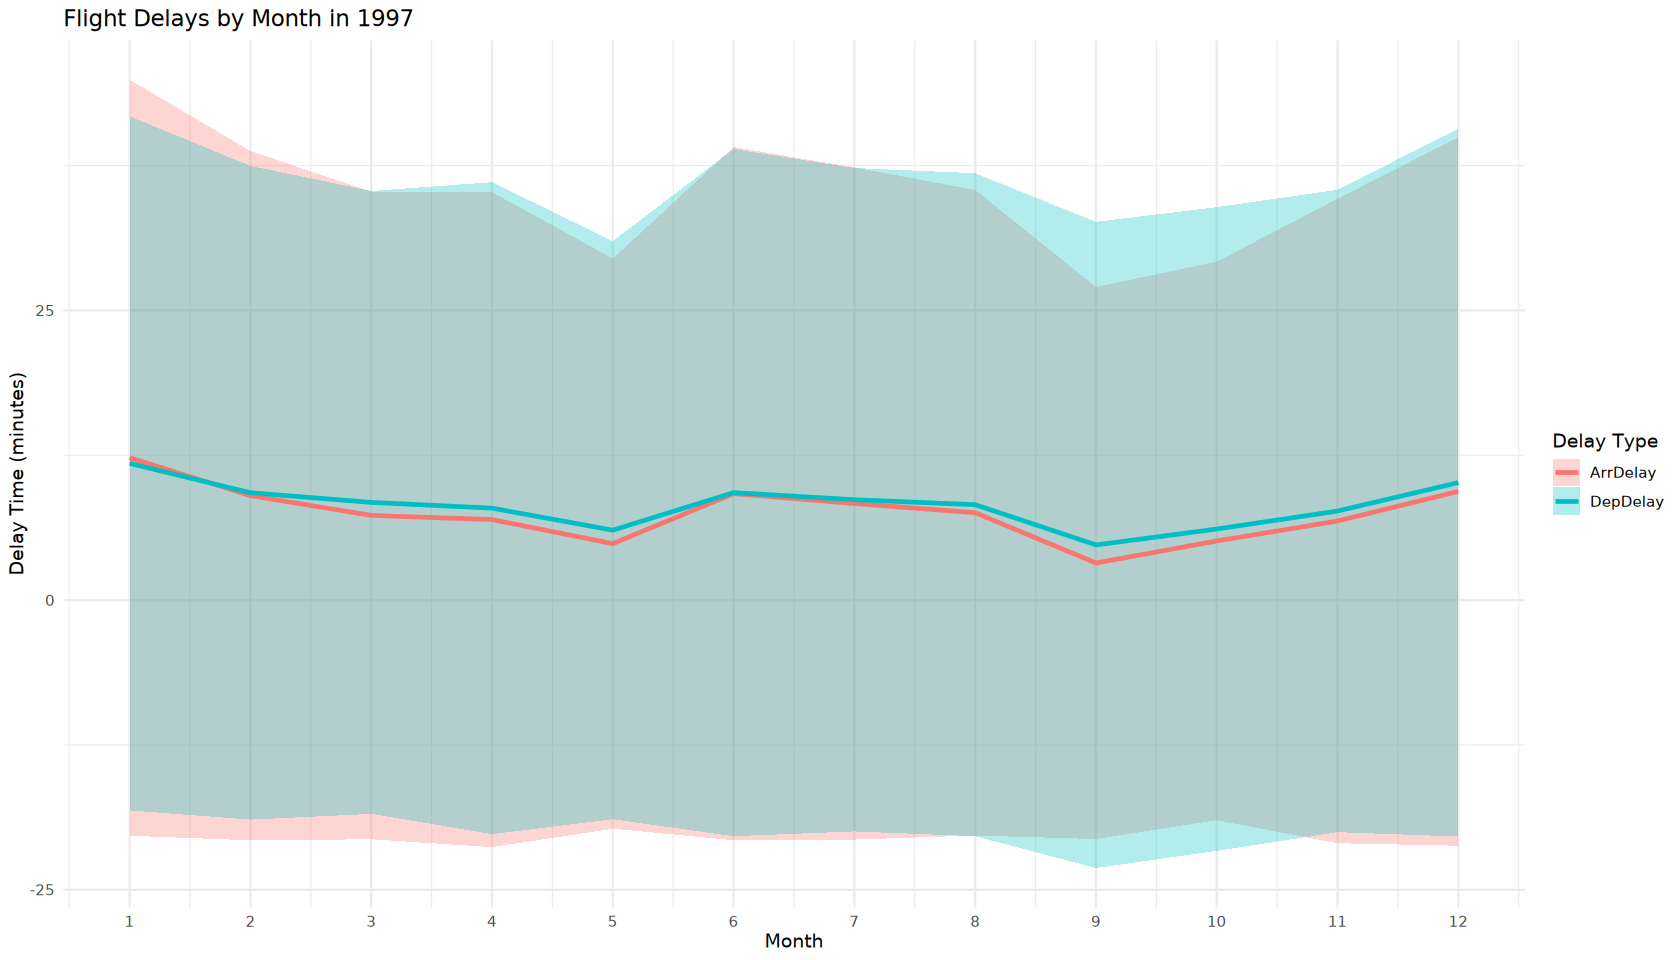

In [17]:
ggplot(summaryDF, aes(x = Month, y = mean, color = name, fill = name)) +
  geom_ribbon(aes(ymin = low, ymax = high), alpha = 0.3, color = NA) +
  geom_line(linewidth = 1) +
  labs(title = "Flight Delays by Month in 1997",
       x = "Month",
       y = "Delay Time (minutes)",
       color = "Delay Type",
       fill = "Delay Type") +
  theme_minimal() +
  scale_x_continuous(breaks = 1:12)

Alternative calculations for ribbon plot: 

Instead of standard deviation, you could calculate and display confidence intervals or interquartile range showing the 25th to 75th percentiles. Using confidence intervals would create a narrower ribbon that focuses on where the true population mean likely falls, giving a more precise estimate of typical delays. Using IQR would show where the middle 50% of delay values fall, which might better represent typical passenger experiences since it's less affected by extreme outliers than standard deviation.

## Building a reusable function to compare delays across four airports

In [18]:
create_summary <- function(data, origin_code) {
  data %>%
    filter(Origin == origin_code) %>%
    select(ArrDelay, DepDelay, Month) %>%
    pivot_longer(cols = c(ArrDelay, DepDelay)) %>%
    group_by(Month, name) %>%
    summarise(mean = mean(value),
              high = mean(value) + sd(value),
              low  = mean(value) - sd(value),
              .groups = 'drop')
}

Function to create summary data for a specific origin

In [19]:
create_delay_plot <- function(summary_data, origin_code) {
  ggplot(summary_data, aes(x = Month, y = mean, color = name, fill = name)) +
    geom_ribbon(aes(ymin = low, ymax = high), alpha = 0.3, color = NA) +
    geom_line(size = 1) +
    labs(title = paste("Flight Delays from", origin_code),
         x = "Month",
         y = "Delay (minutes)",
         color = "Delay Type",
         fill = "Delay Type") +
    theme_minimal() +
    scale_x_continuous(breaks = 1:12) +
    theme(legend.position = "bottom")
}

Function to create a plot for a specific origin

In [21]:
summary_PHX <- create_summary(myDF_clean, "PHX")
summary_ORD <- create_summary(myDF_clean, "ORD")
summary_ATL <- create_summary(myDF_clean, "ATL")
summary_LAX <- create_summary(myDF_clean, "LAX")

Create summaries for different origins and create individual plots

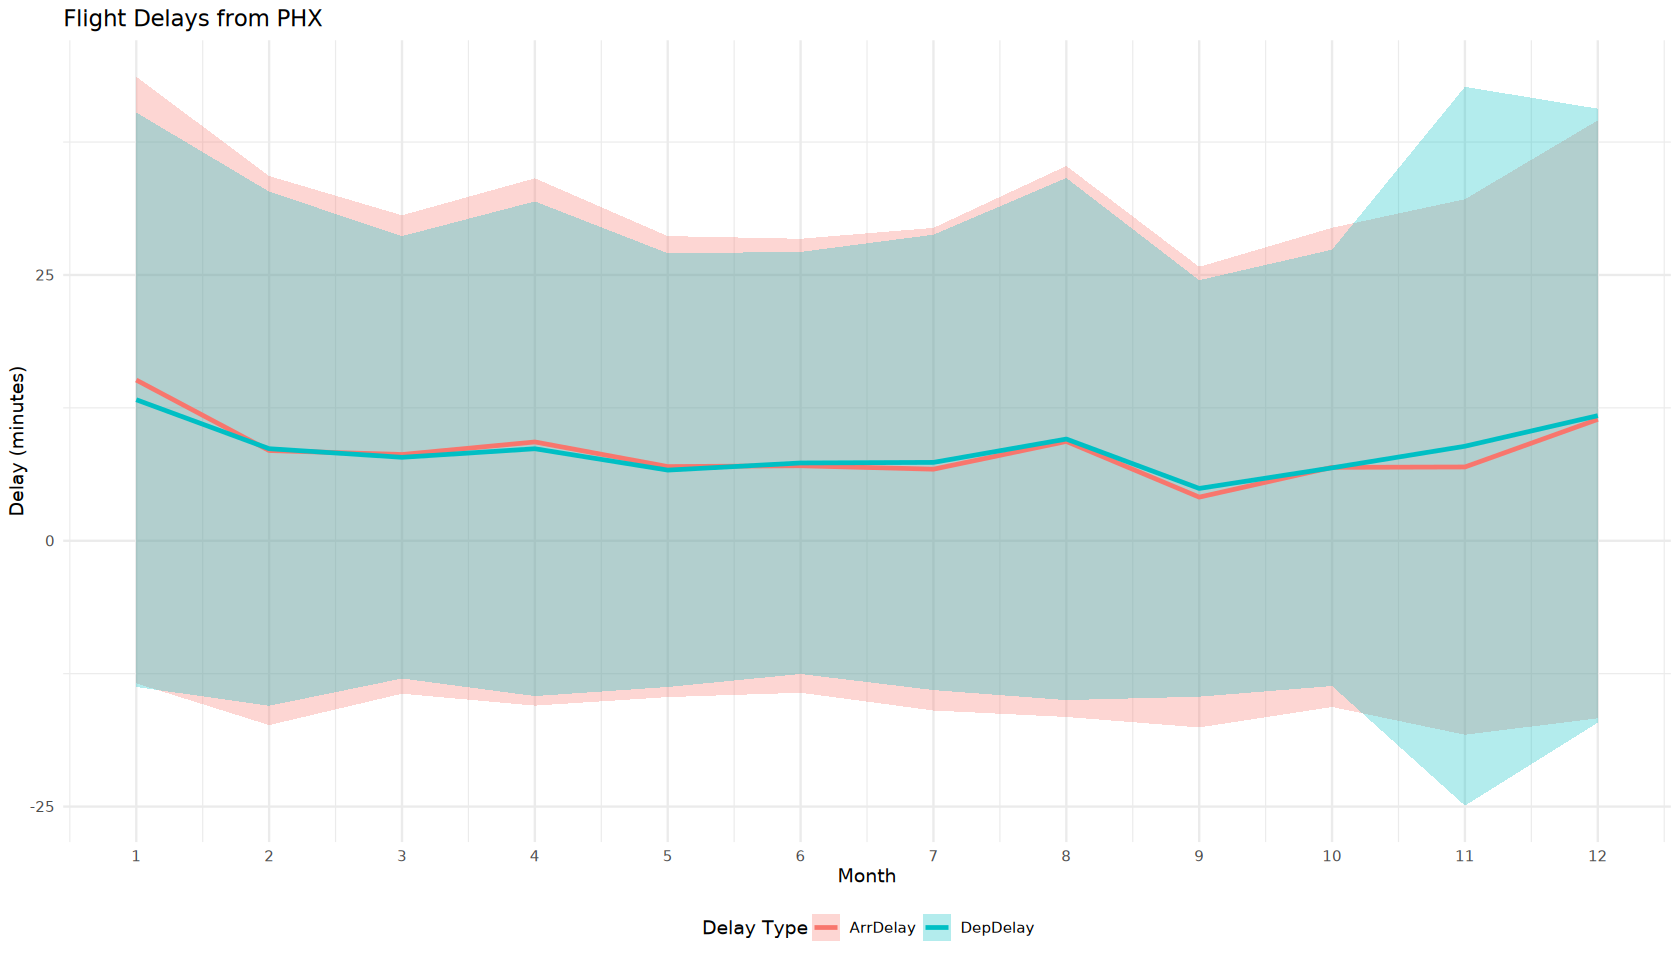

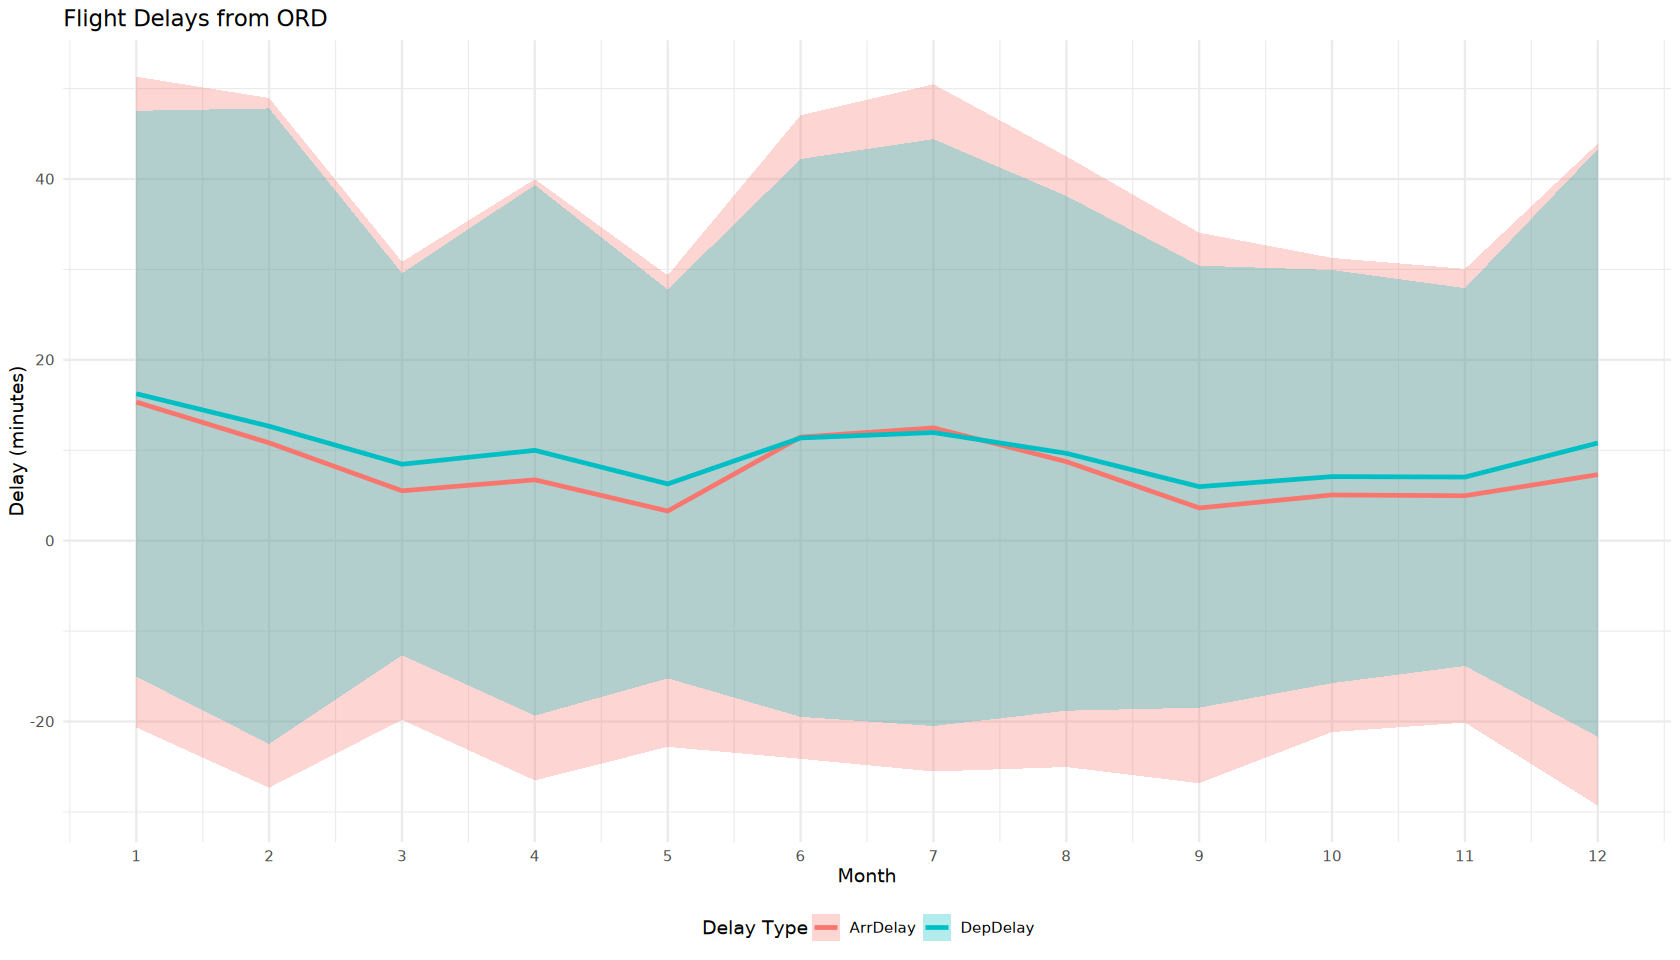

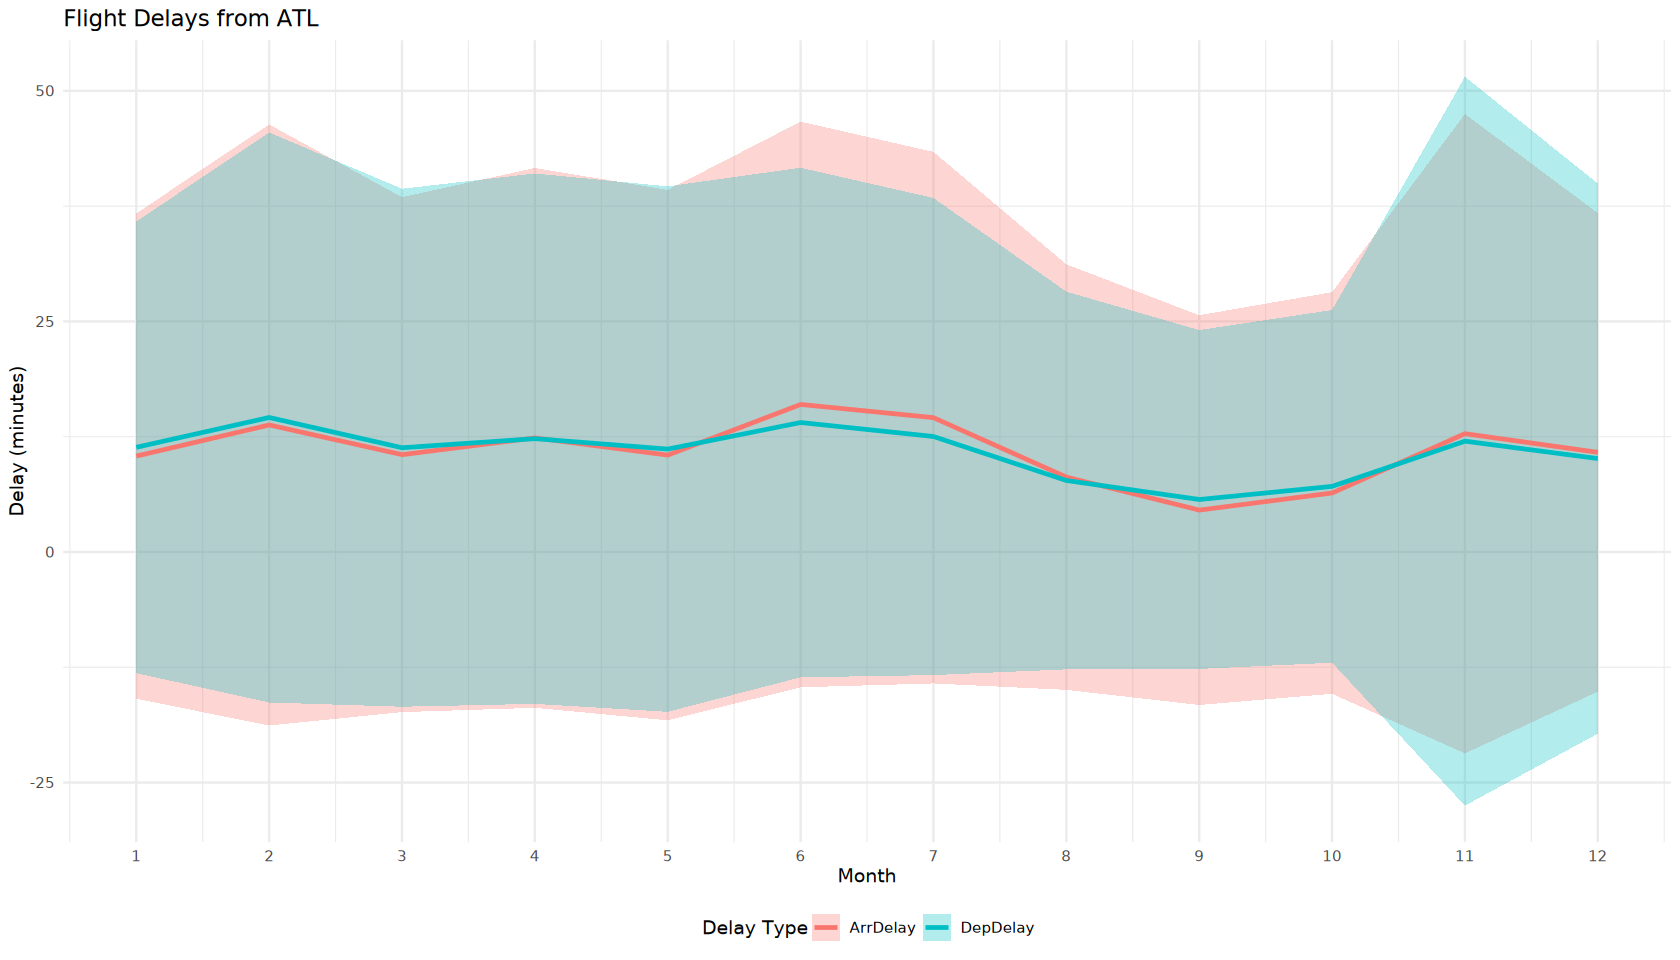

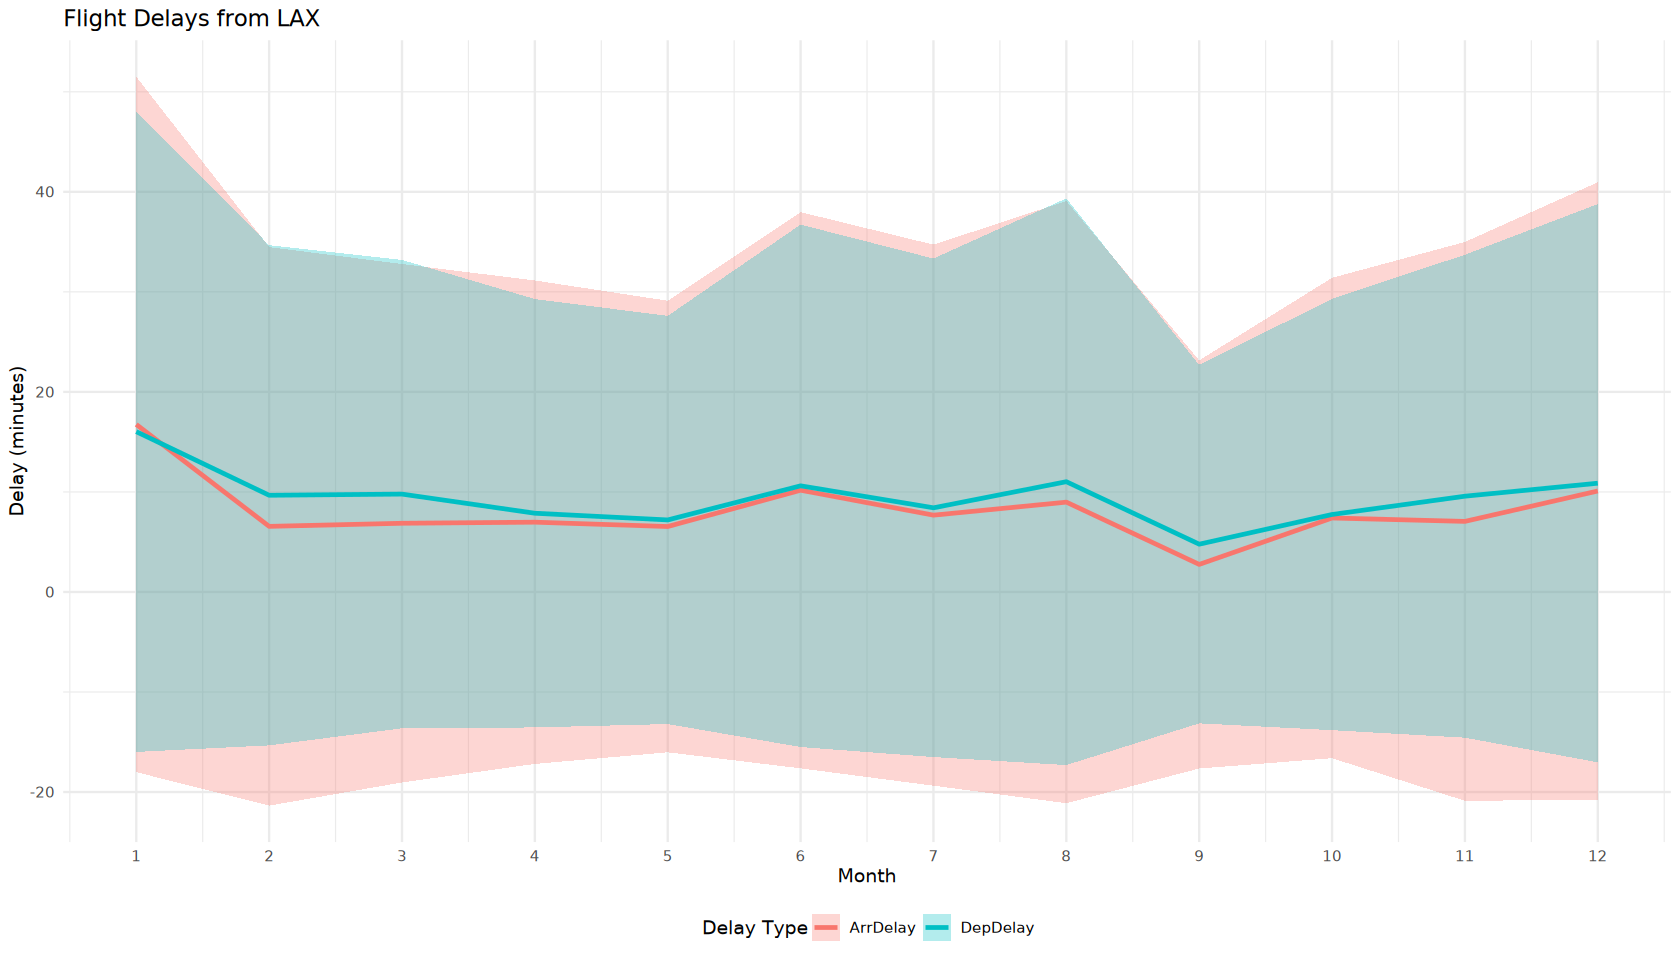

In [24]:
p_PHX <- create_delay_plot(summary_PHX, "PHX")
p_ORD <- create_delay_plot(summary_ORD, "ORD")
p_ATL <- create_delay_plot(summary_ATL, "ATL")
p_LAX <- create_delay_plot(summary_LAX, "LAX")

p_PHX
p_ORD
p_ATL
p_LAX

Across all airports, departure delays and arrival delays tend to follow similar patterns within each month, showing that delays at departure often translate to delays at arrival. The plots reveal that winter months (December-February) and summer months (June-August) typically have higher delays, likely due to weather conditions and increased travel volume. Comparing different origins, major hub airports like ORD (Chicago) and ATL (Atlanta) show higher average delays and greater variability compared to PHX. LAX shows particularly high delays during summer months.

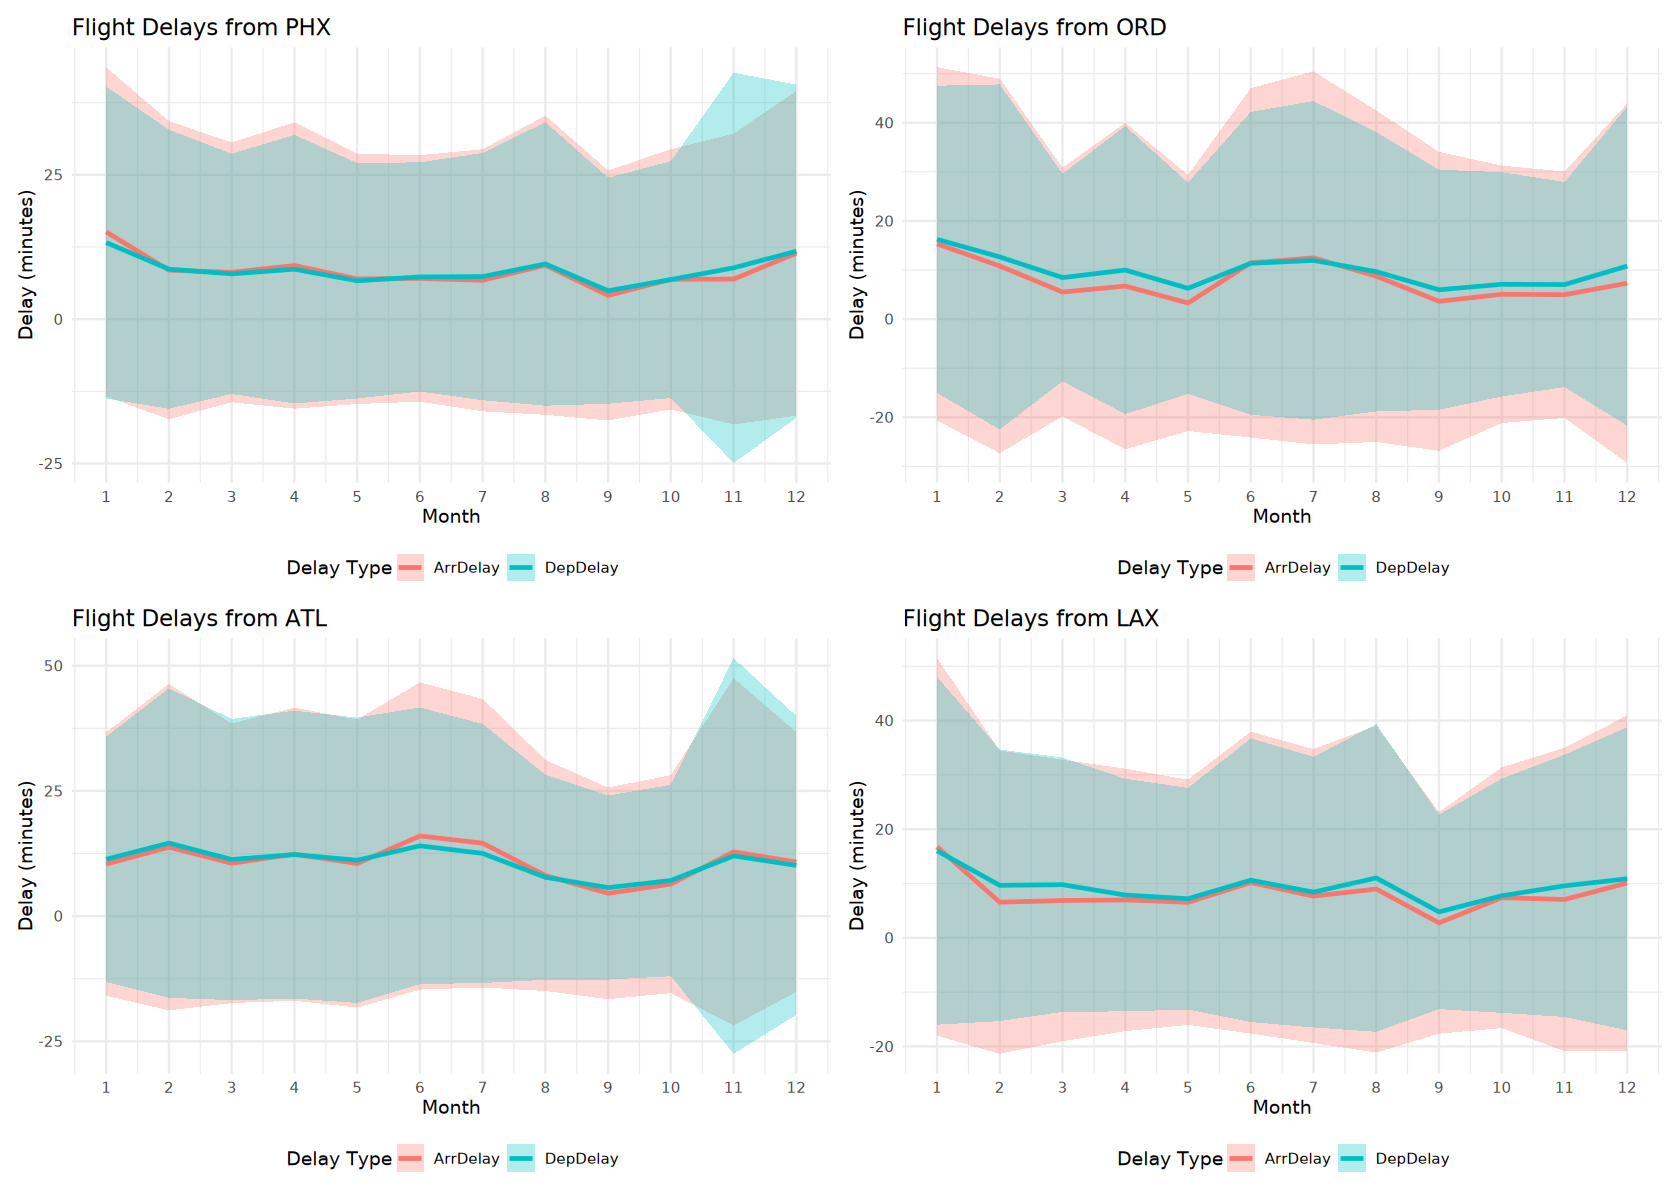

In [25]:
# Arrangement 1: Simple 2x2 grid
options(repr.plot.width = 14, repr.plot.height = 10)
p_PHX + p_ORD + p_ATL + p_LAX

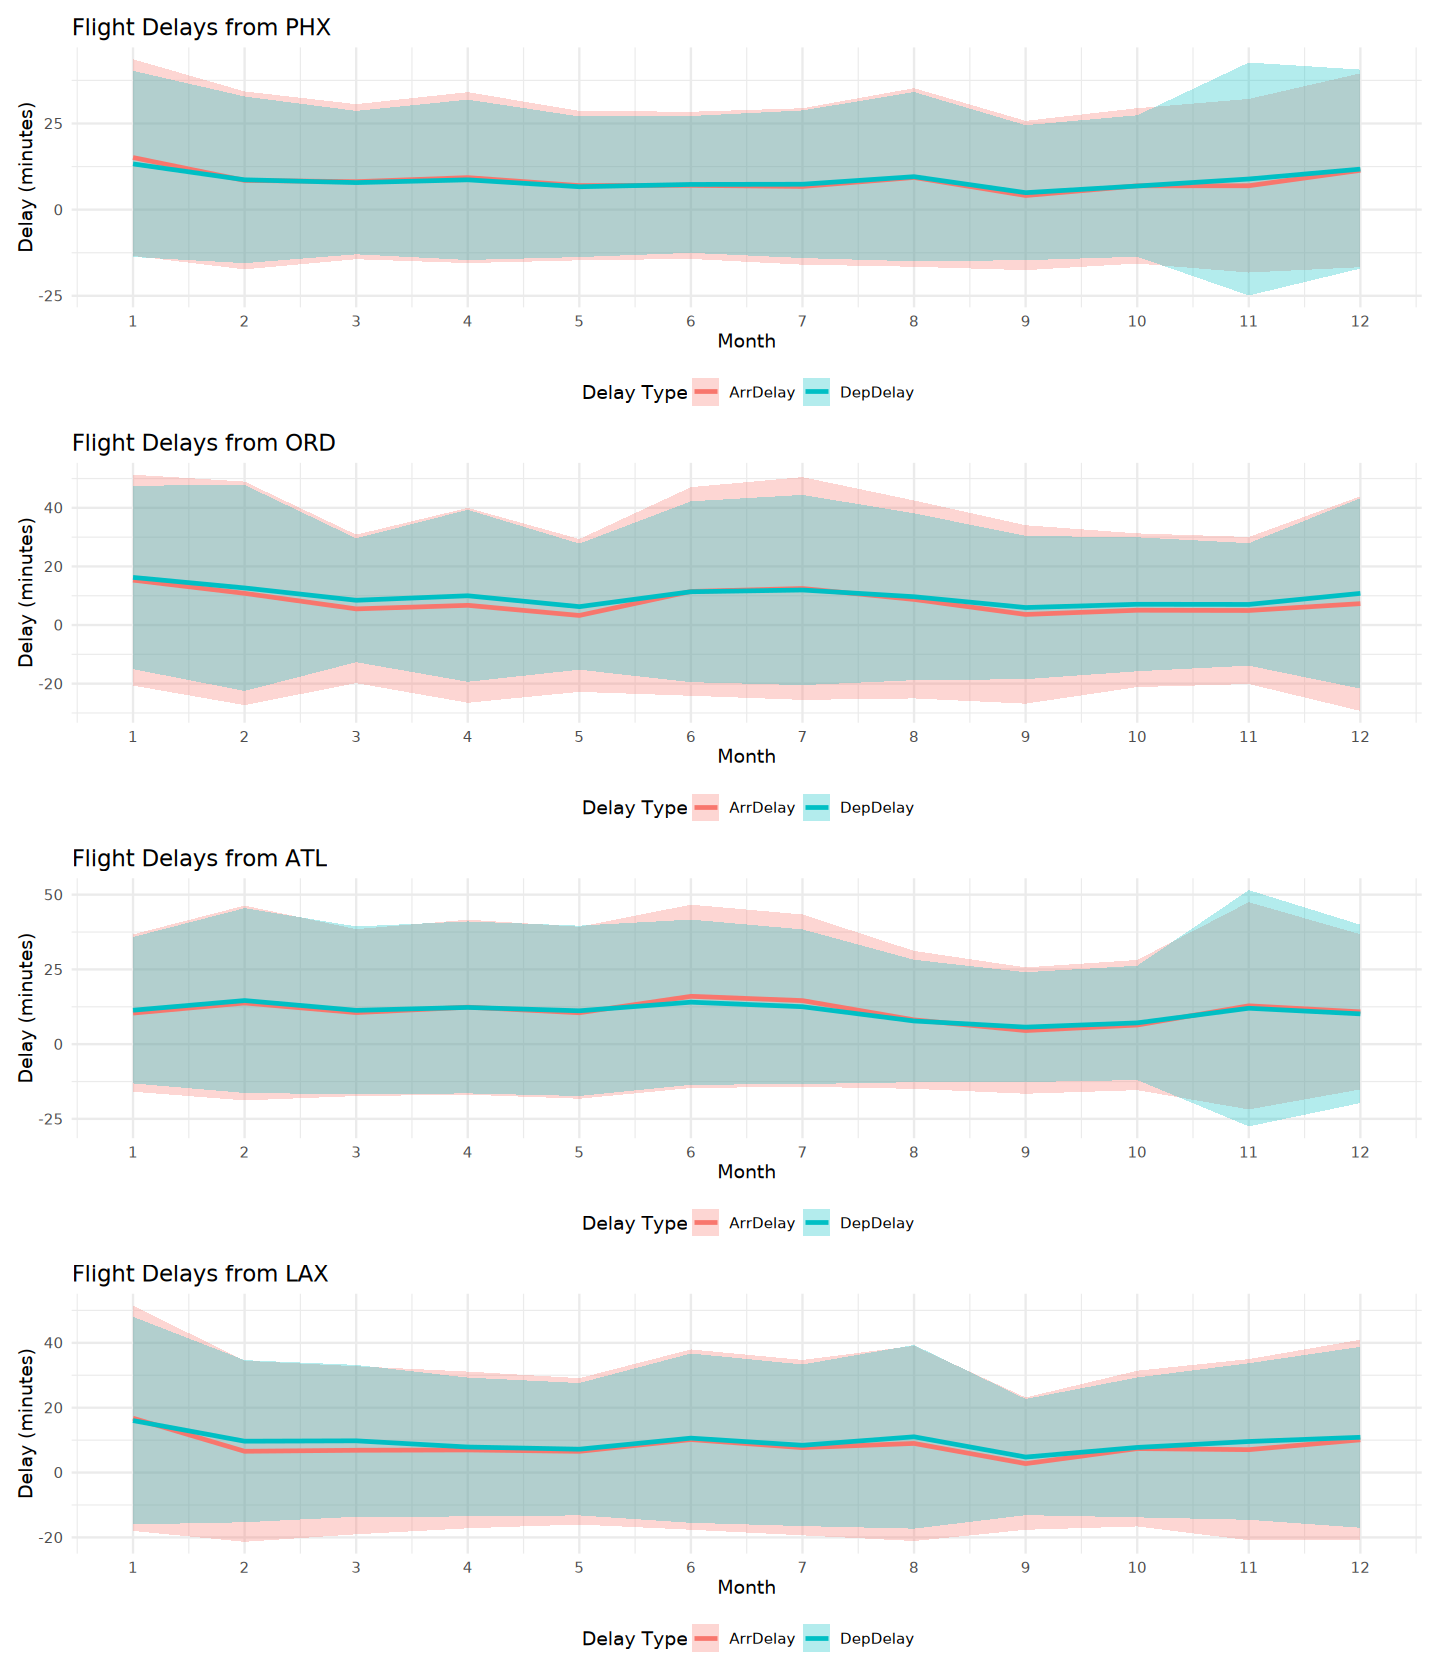

In [26]:
# Arrangement 2: Vertical stack
options(repr.plot.width = 12, repr.plot.height = 14)
p_PHX / p_ORD / p_ATL / p_LAX

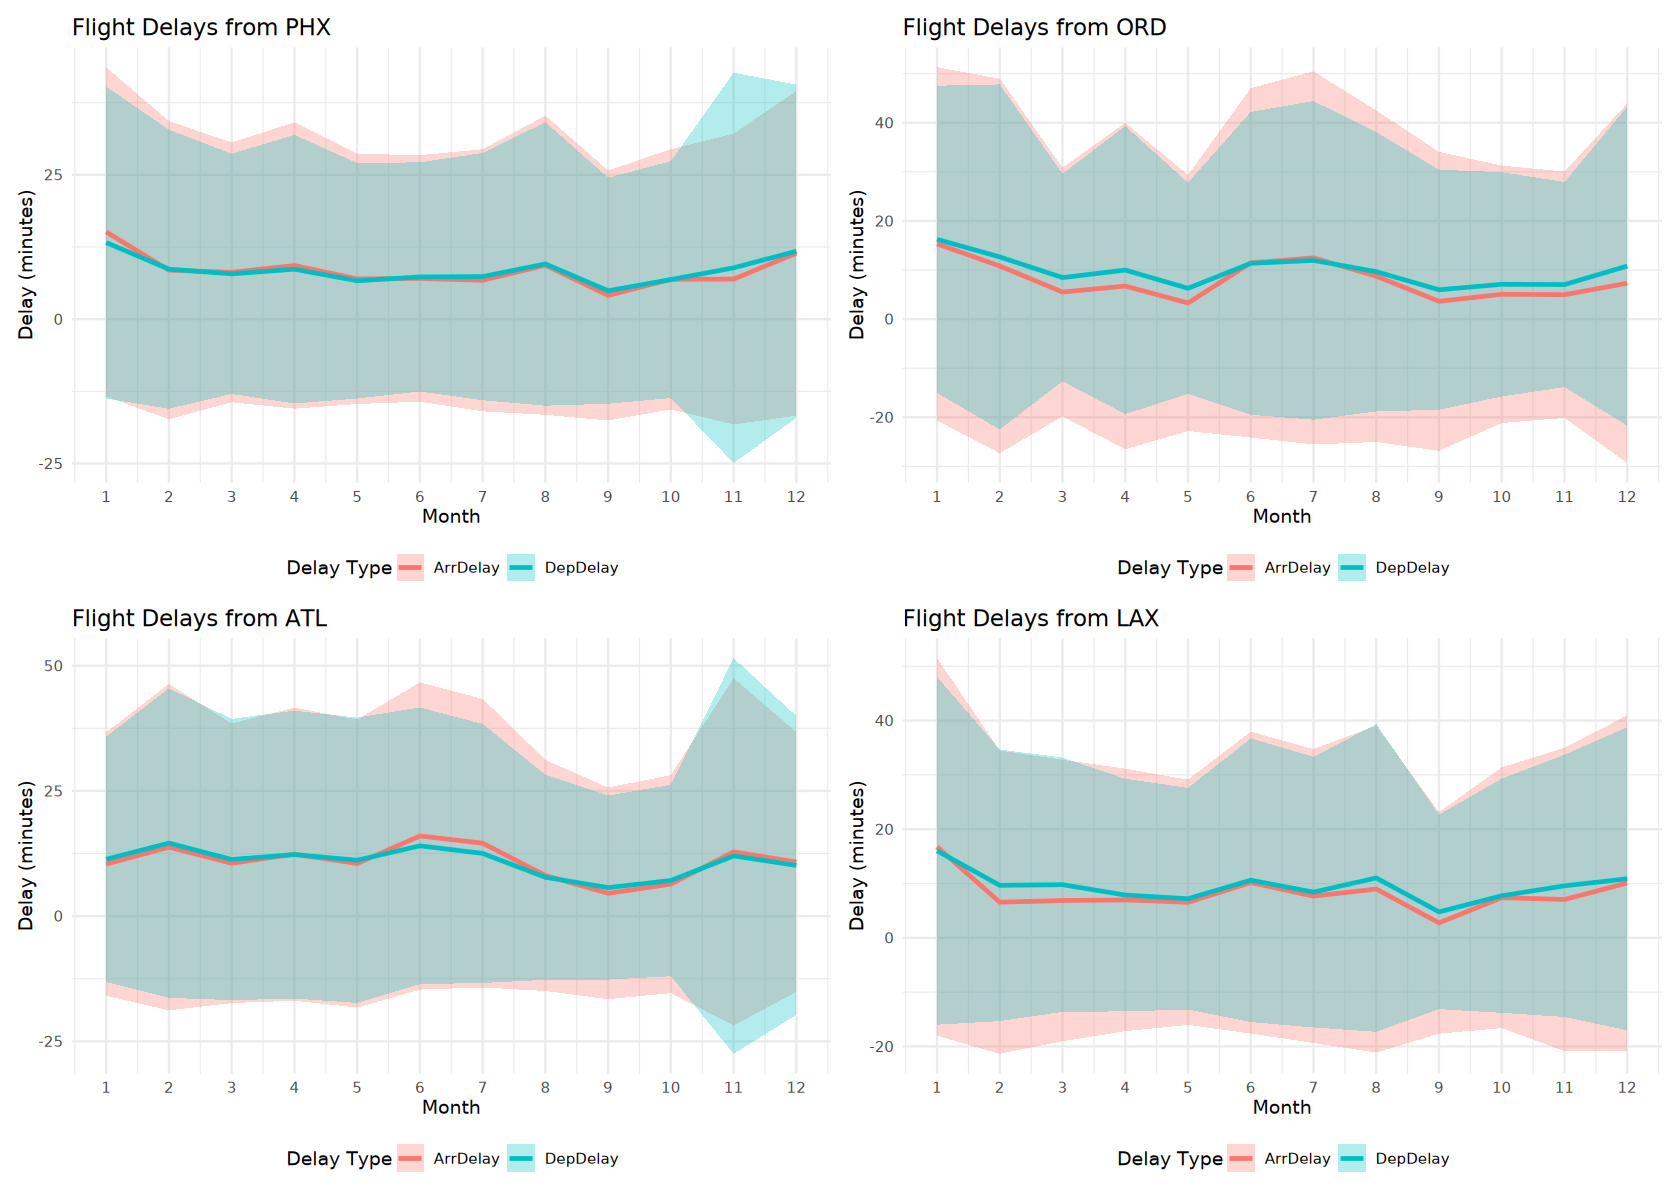

In [27]:
# Arrangement 3: Custom layout with wrap_plots
options(repr.plot.width = 14, repr.plot.height = 10)
wrap_plots(A = p_PHX, B = p_ORD, C = p_ATL, D = p_LAX, 
           design = "AB\nCD")

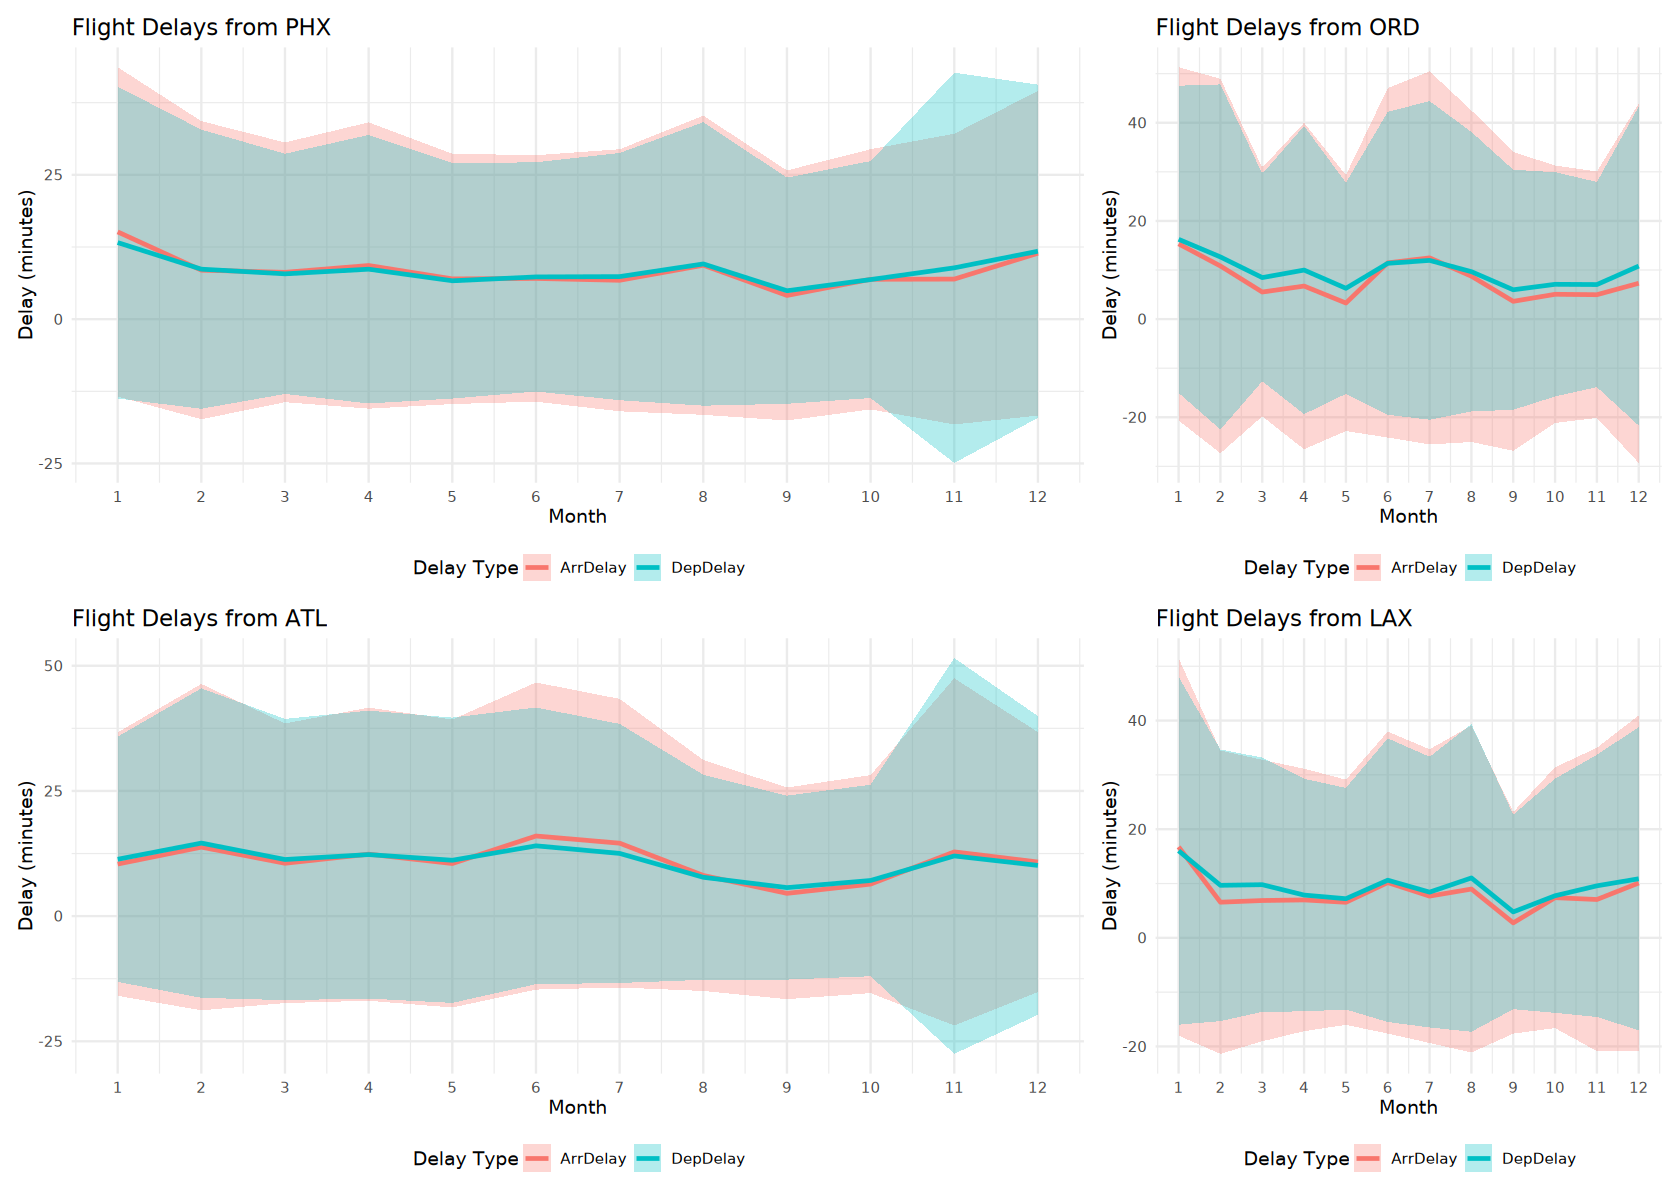

In [28]:
# Arrangement 4: Custom asymmetric layout
options(repr.plot.width = 14, repr.plot.height = 10)
wrap_plots(A = p_PHX, B = p_ORD, C = p_ATL, D = p_LAX,
           design = "AAB\nCCD")

I feel that the 2x2 grid layout is typically the most balanced for comparing four plots side-by-side.

## Good plot vs. bad plot: demonstrating data visualization design principles

In [29]:
myDF <- read.csv('/anvil/projects/tdm/data/zillow/Metro_time_series.csv')

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


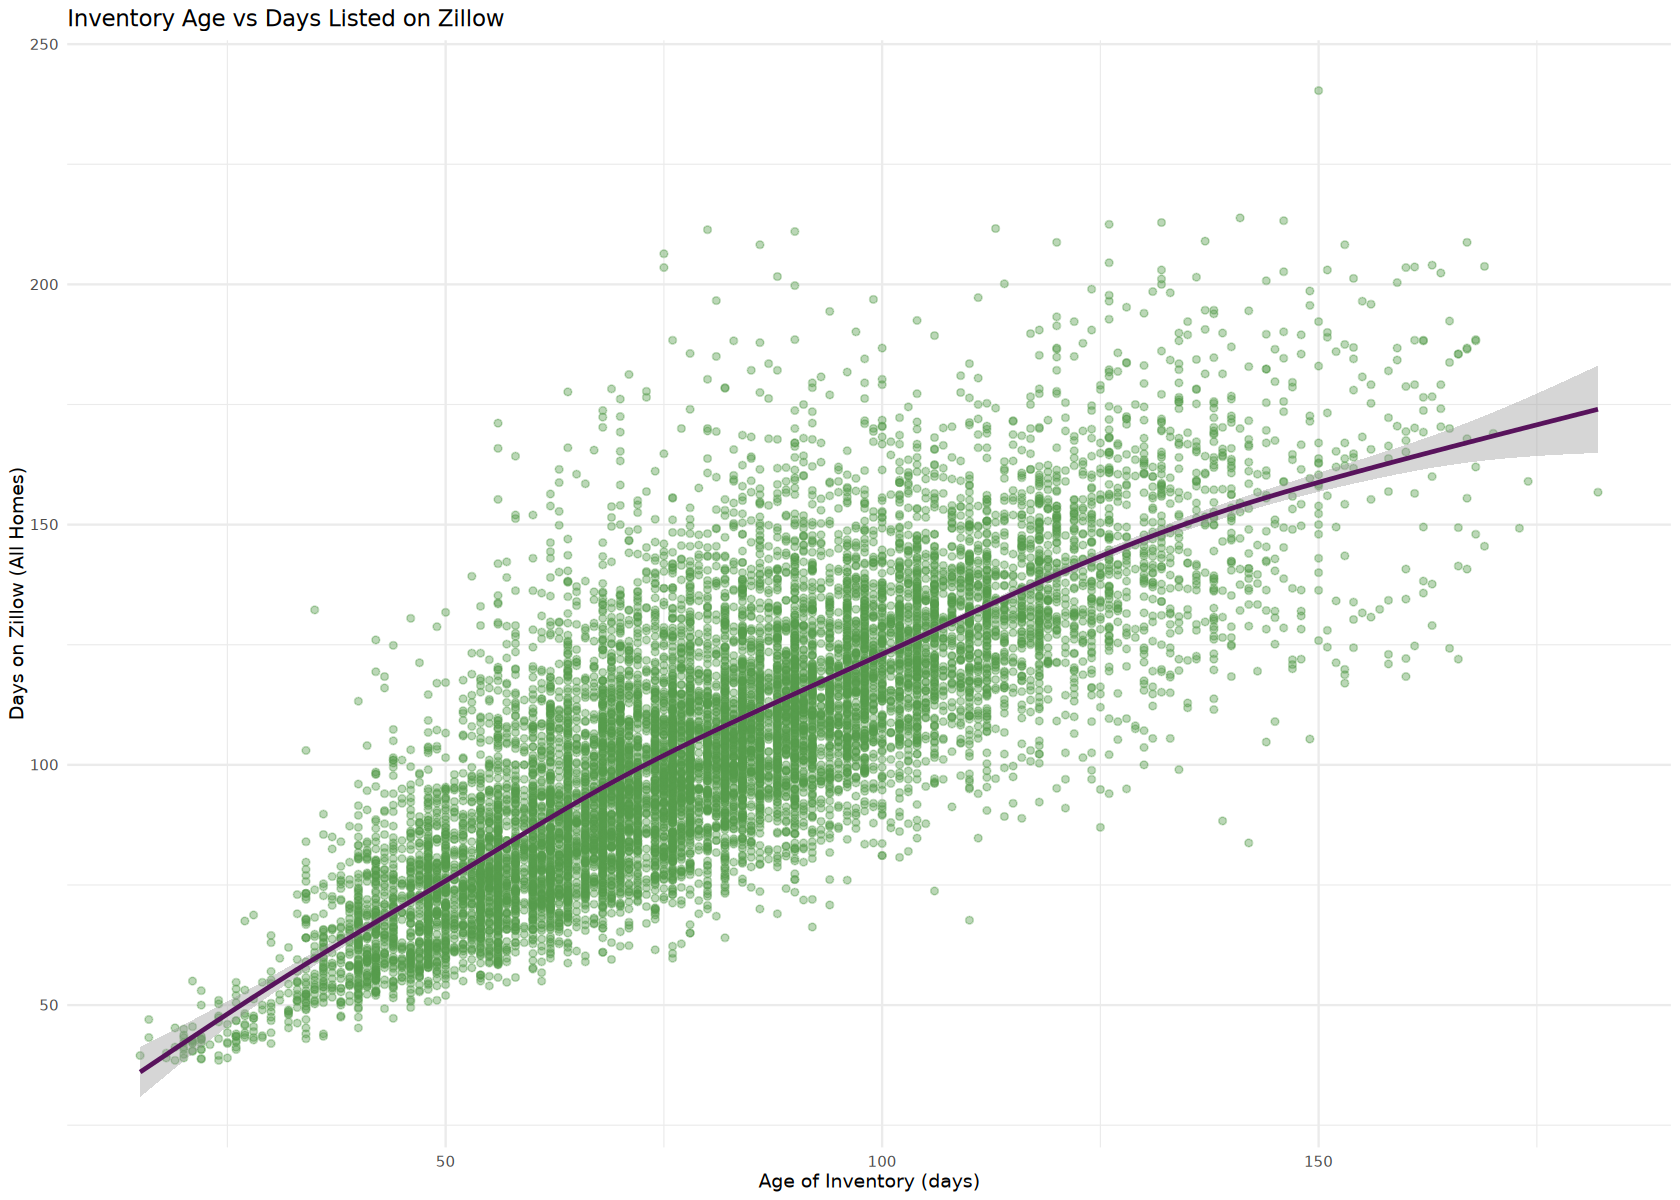

In [30]:
# Example Plot #1 (GOOD)
myDF_clean <- myDF %>%
  filter(!is.na(AgeOfInventory), !is.na(DaysOnZillow_AllHomes))

ggplot(myDF_clean, aes(x = AgeOfInventory, y = DaysOnZillow_AllHomes)) +
  geom_point(alpha = 0.4, color = "#559c4b") +
  geom_smooth(color = "#58135c") +
  labs(title = "Inventory Age vs Days Listed on Zillow",
       x = "Age of Inventory (days)",
       y = "Days on Zillow (All Homes)") +
  theme_minimal()

`geom_smooth()` using method = 'gam'


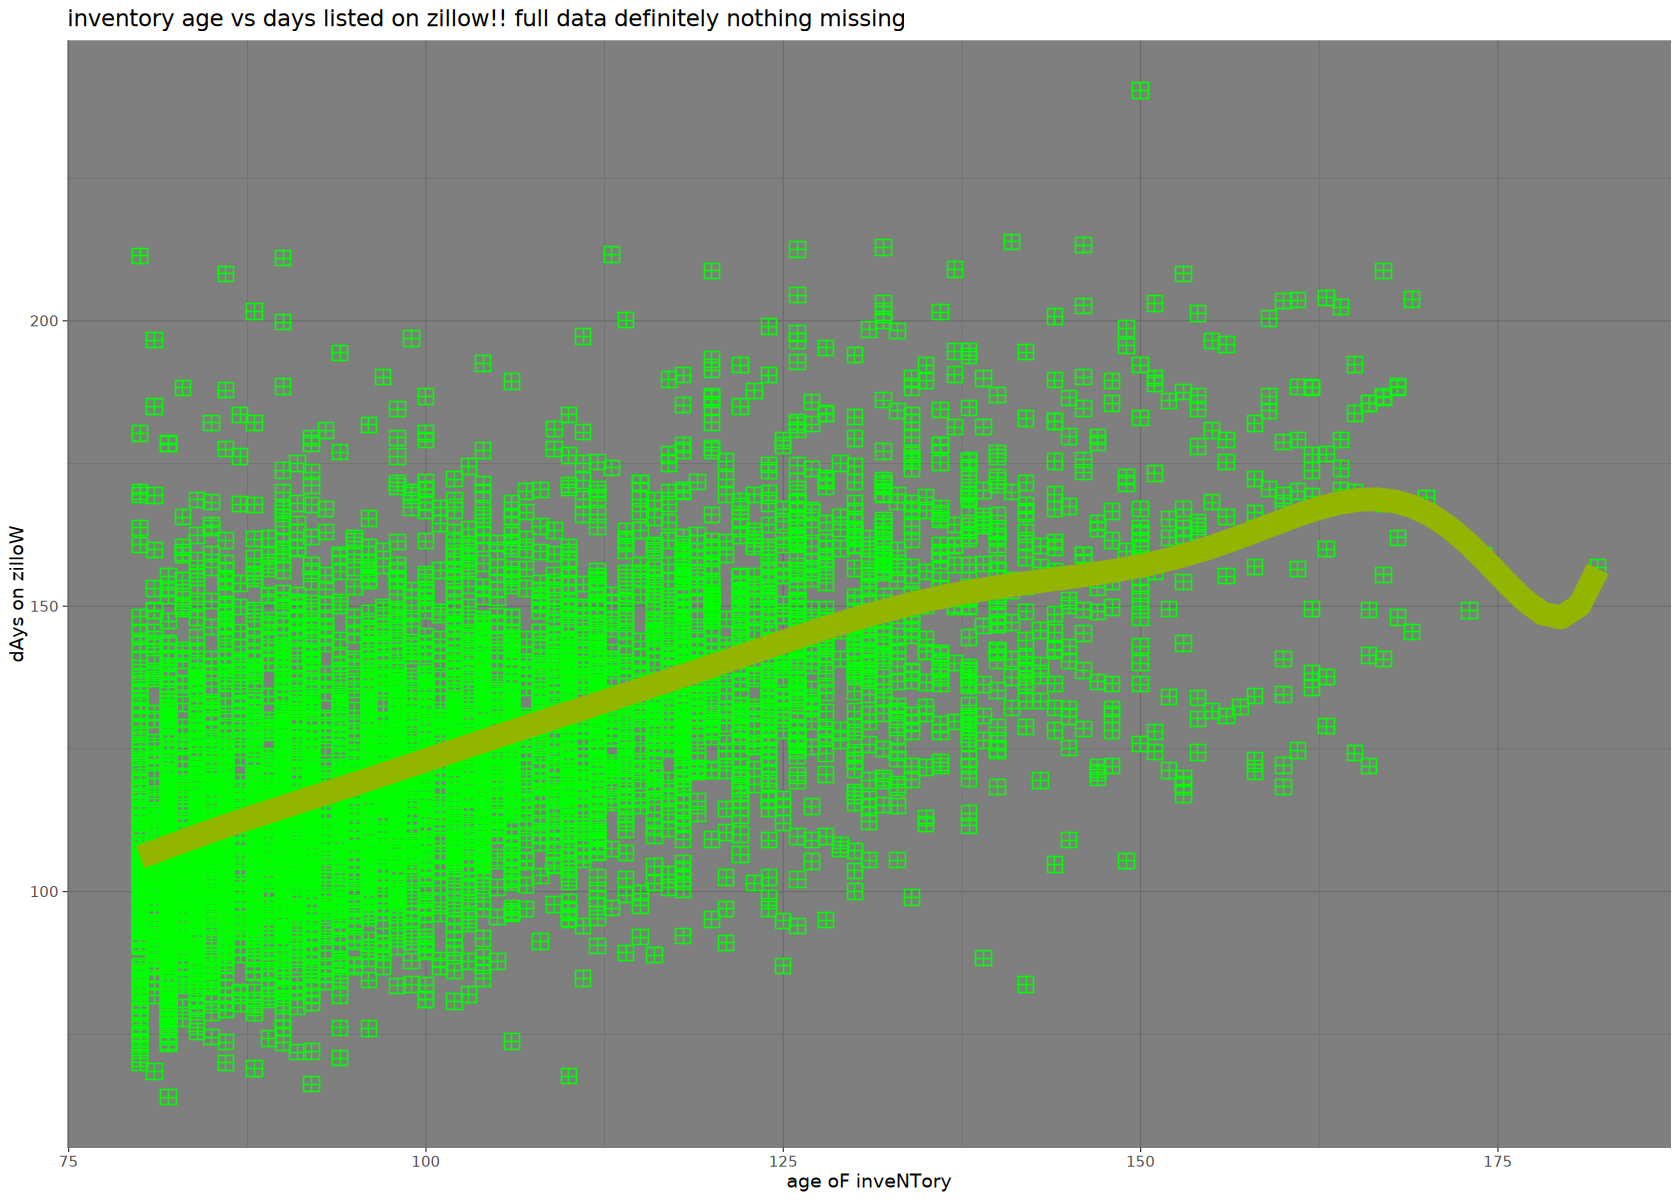

In [31]:
# Example Plot #2 (BAD)
myDF_bad <- myDF_clean %>%
    filter(AgeOfInventory > quantile(AgeOfInventory, 0.50))

ggplot(myDF_bad, aes(x = AgeOfInventory, y = DaysOnZillow_AllHomes)) +
  geom_point(color = "green", shape=12, size=4) +
  geom_smooth(formula = y ~ poly(x, 10),
              se = FALSE,
              color = "#91b500",
              linewidth = 5) +
  labs(title = "inventory age vs days listed on zillow!! full data definitely nothing missing",
       x = "age oF inveNTory",
       y = "dAys on zilloW") +
  theme_dark()

In [43]:
library(lubridate)

myDF_time <- myDF %>%
  filter(!is.na(Date), !is.na(MedianListingPrice_AllHomes)) %>%
  mutate(new_date = as.Date(Date, format = "%Y-%m-%d")) %>%
  group_by(new_date) %>%
  summarize(avg_price = mean(MedianListingPrice_AllHomes, na.rm = TRUE)) %>%
  ungroup()

myDF_time2 <- myDF_time %>%
  filter(new_date >= min(new_date) + months(30), new_date <= max(new_date) - months(40))

Shape the data for plots #3 and #4

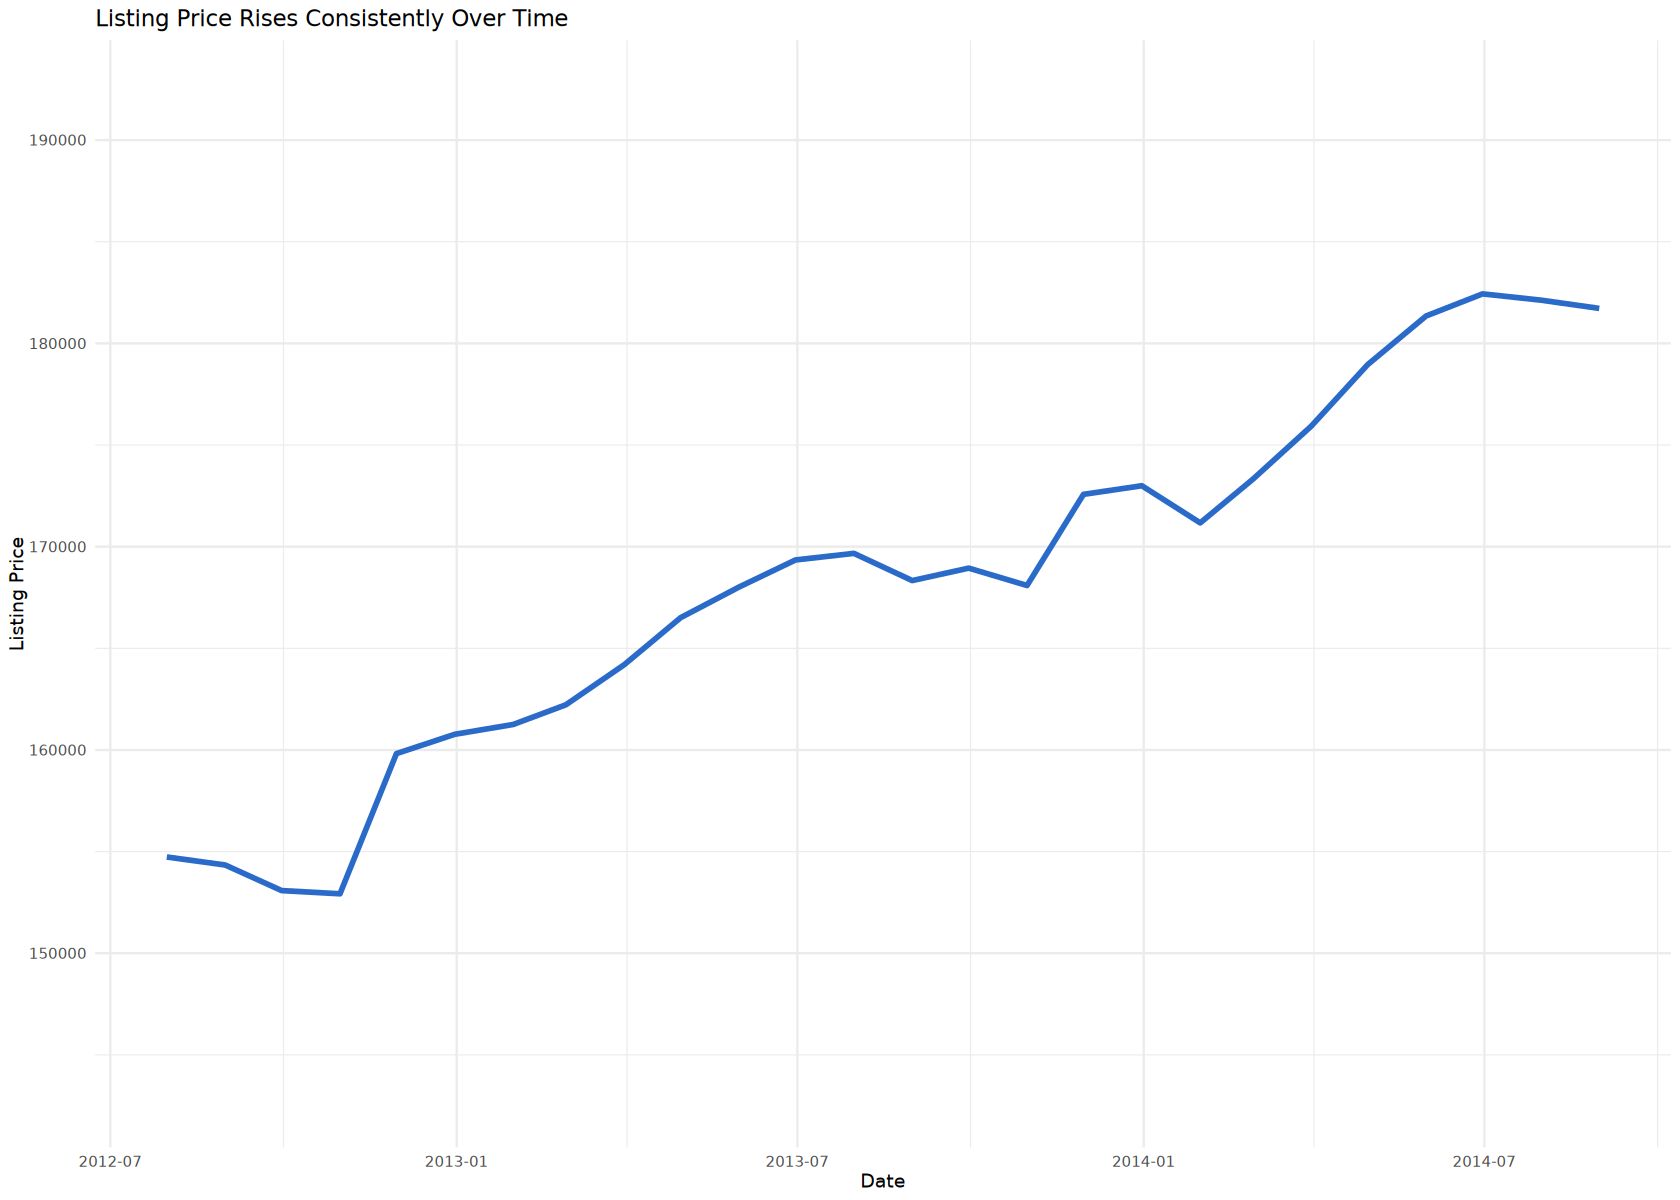

In [44]:
# Example Plot #3 (BAD)
ggplot(myDF_time2, aes(x = new_date, y = avg_price)) +
  geom_line(color = "#2a6ac9", size = 1.2) +
  labs(title = "Listing Price Rises Consistently Over Time",
       x = "Date",
       y = "Listing Price") +
  theme_minimal() +
  scale_y_continuous(limits = c(min(myDF_time2$avg_price) - 10000,
                                max(myDF_time2$avg_price) + 10000))


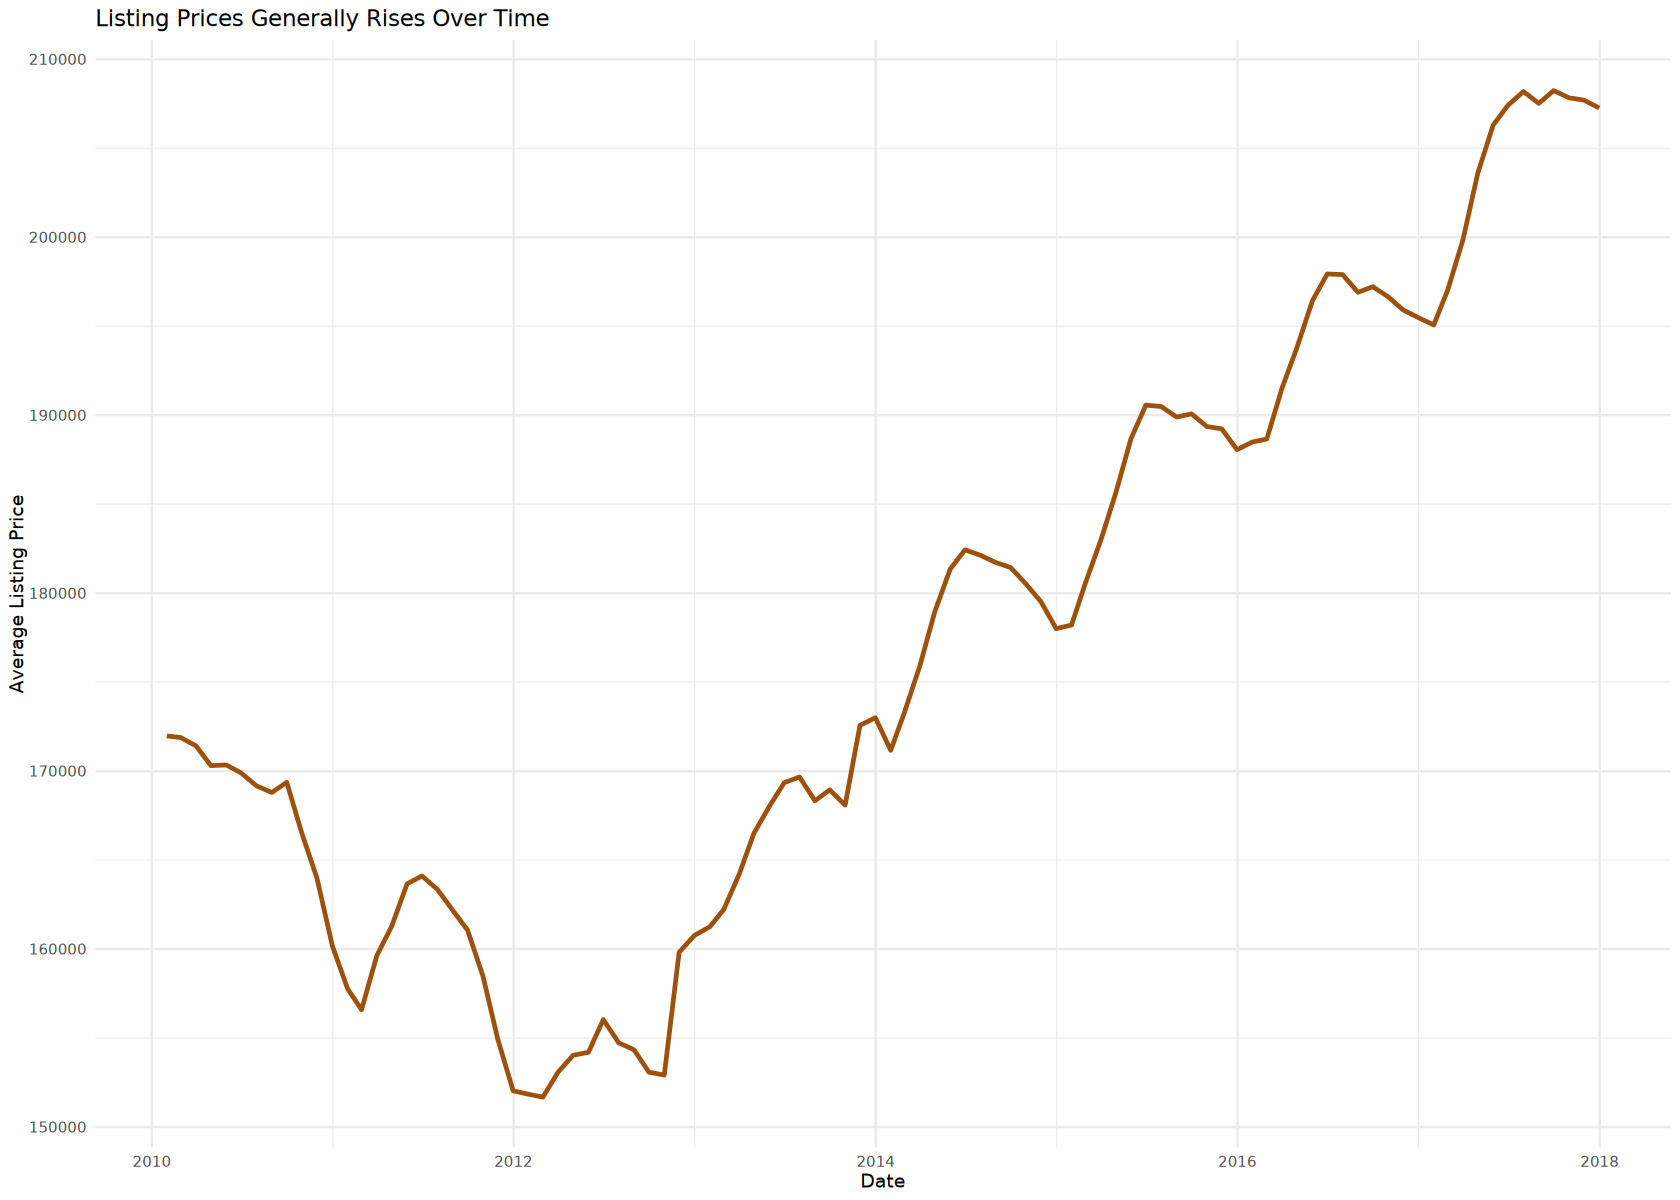

In [45]:
# Example Plot #4 (GOOD)
ggplot(myDF_time, aes(x = new_date, y = avg_price)) +
  geom_line(color = "#9e510d", size = 1) +
  labs(title = "Listing Prices Generally Rises Over Time",
       x = "Date",
       y = "Average Listing Price") +
  theme_minimal()

Good Plot Components:
- Clear, properly formatted titles and axis labels with consistent capitalization
- Uses all relevant data without misleading filtering
- Appropriate smoothing methods that don't overfit the data
- Reasonable alpha transparency for overlapping points
- Clean, readable theme (like theme_minimal)
- Honest representation of the full dataset
- Descriptive and accurate titles that don't make false claims

Bad Plot Components:
- Inconsistent or unprofessional formatting (random capitalization, excessive punctuation)
- Misleading data filtering (removing half the data in Plot #2, removing middle years in Plot #3)
- Overfitting with polynomial smoothing that creates false patterns
- Distracting visual elements (large point sizes, harsh colors, dark themes that reduce readability)
- Dishonest titles claiming to show "full data" when data is actually filtered
- Manipulated axes or time ranges to exaggerate trends

Analysis of Example Plots:
1. Plot #1 (GOOD): Uses all the data after filtering NAs, has clear labels, appropriate transparency, and a reasonable smoothing curve that shows the general trend without overfitting.
2. Plot #2 (BAD): Filters out 50% of the data (below median), uses an overly complex polynomial fit that creates artificial patterns, has unprofessional formatting, and dishonestly claims to show "full data definitely nothing missing" when half the data is removed.
3. Plot #3 (BAD): Removes 30 months from the beginning and 40 months from the end of the dataset, cherry-picking a time period that shows consistent growth while hiding the full picture of price fluctuations. The title claims prices "rise consistently" which is only true for this manipulated subset.
4. Plot #4 (GOOD): Shows the complete time series data, revealing the actual pattern including market crashes and recoveries. The title honestly states prices "generally rise" which is more accurate and doesn't overstate the pattern.

How observations relate to plot quality:

Plot quality is really about being honest and clear with your data. Plots #2 and #3 show how someone could easily trick viewers by cutting out data they don't want to show or only picking certain time periods. The good plots (#1 and #4) show all the data and use honest titles that don't exaggerate what's happening. Even the messy formatting in Plot #2 (weird capitalization and too many exclamation marks) isn't just ugly—it's a red flag that the person making it might not be trustworthy. When a plot looks professional and clean, it usually means the person making it also cared about showing the data honestly.

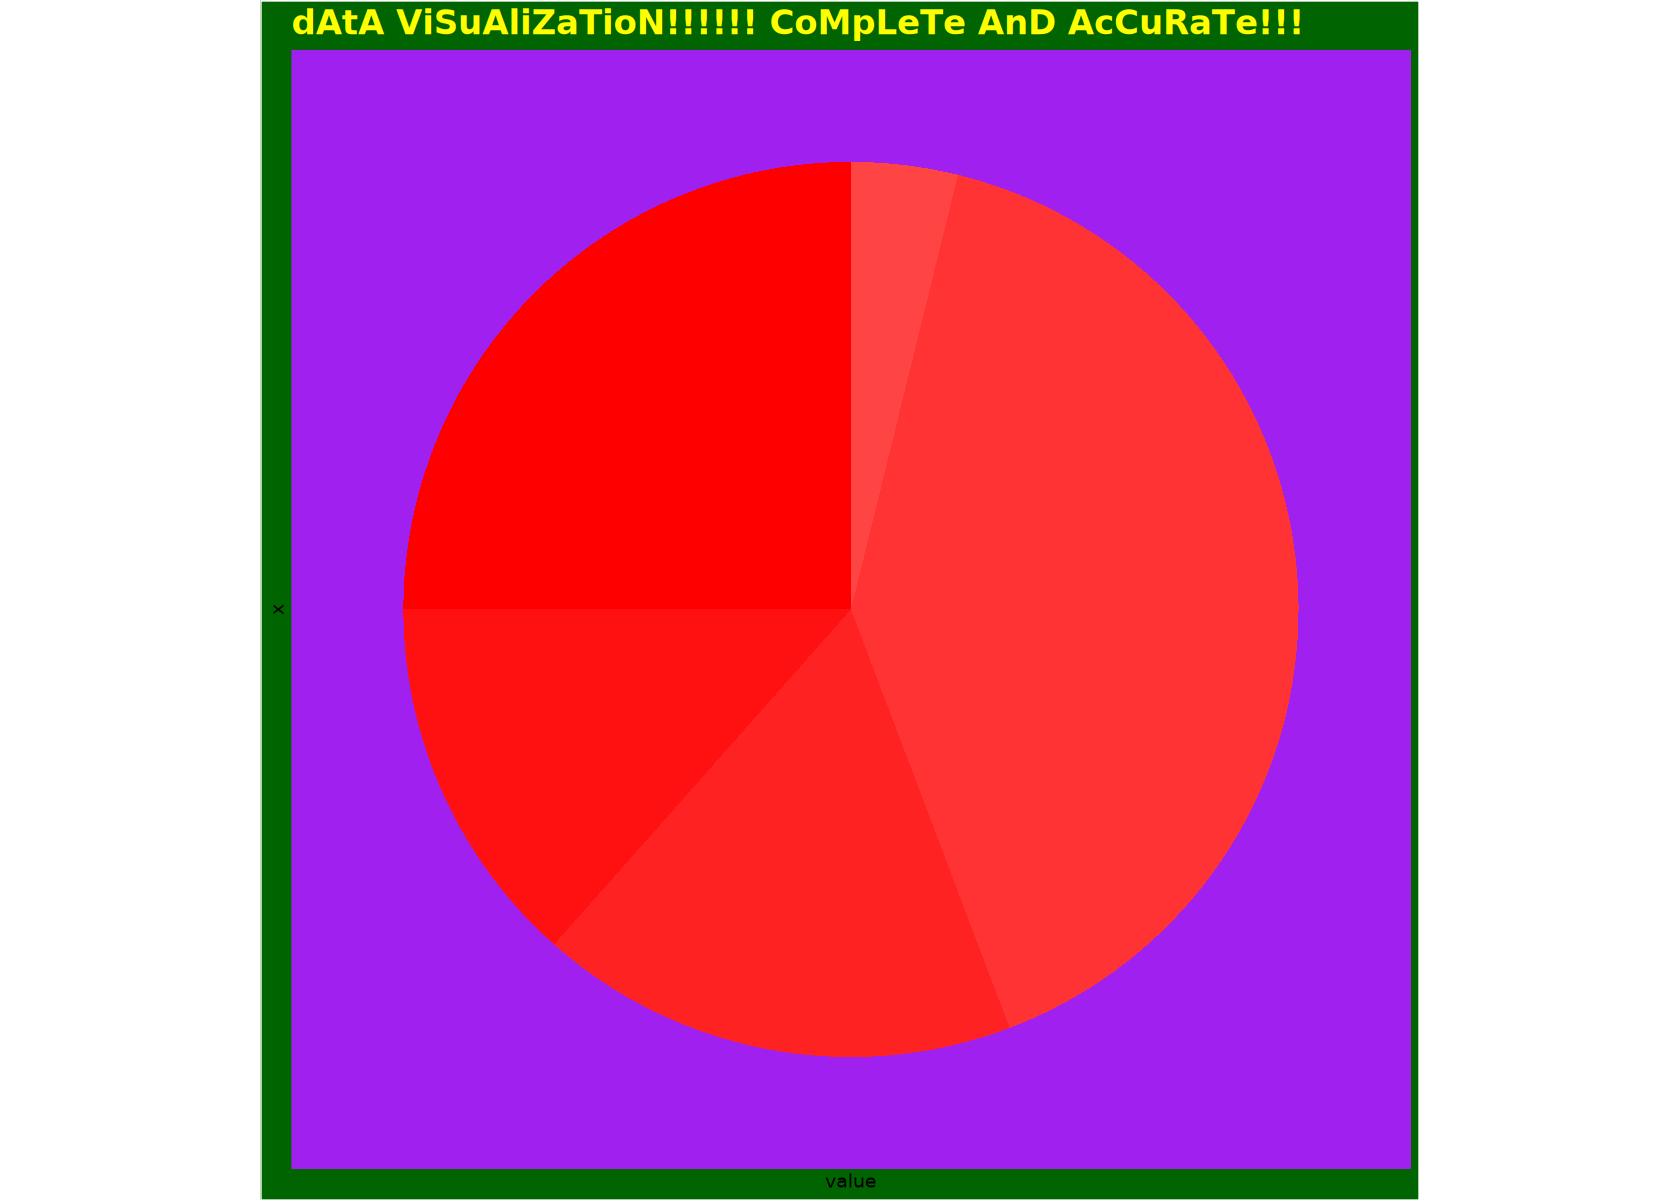

In [46]:
data <- data.frame(
  group=LETTERS[1:5],
  value=c(13,7,9,21,2)
)

ggplot(data, aes(x="", y=value, fill=group)) +
  geom_bar(stat="identity", width=1) +
  coord_polar("y", start=0) +
  scale_fill_manual(values = c("#FF0000", "#FF1111", "#FF2222", "#FF3333", "#FF4444")) +
  labs(title = "dAtA ViSuAliZaTioN!!!!!! CoMpLeTe AnD AcCuRaTe!!!",
       fill = "gRoUpS") +
  theme_dark() +
  theme(
    plot.title = element_text(size = 20, face = "bold", color = "yellow"),
    legend.position = "none",
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    plot.background = element_rect(fill = "darkgreen"),
    panel.background = element_rect(fill = "purple")
  )

Create terrible pie chart and display

Markdown notes and full English sentences and analysis written here.

Markdown notes and full English sentences and analysis written here.

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
